<style>
.phnx-title{background:#253746;color:#fff;border-radius:12px;padding:22px 26px;margin:4px 0 18px 0;line-height:1.48}
.phnx-card{background:#F7F4EE;border:1px solid #D6BE91;border-left:6px solid #A86F44;border-radius:10px;padding:15px 19px;margin:10px 0 17px 0;line-height:1.55;color:#2B2B2B}
.phnx-card h2,.phnx-card h3{color:#253746;margin-top:0}
.phnx-cell{display:inline-block;font:600 11px/1.2 sans-serif;letter-spacing:.08em;background:#E8E1D5;color:#51483D;border-radius:999px;padding:4px 8px;margin-bottom:8px}
.phnx-note{background:#EEF2F4;border-left-color:#657984}
.phnx-freeze{background:#F2F6F0;border-left-color:#567A53}
.phnx-warn{background:#FBF0ED;border-left-color:#A14D3B}
.phnx-card code{background:#ECE8E1;padding:1px 4px;border-radius:4px}
</style><div class="phnx-title"><div class="phnx-cell">CELL 01</div>
<h1 style="margin:0 0 8px 0">Probabilistic Day-Ahead Electricity Load Forecasting</h1>
<p style="margin:0"><strong>Spectral structure, leakage-safe transparent forecasts, and probabilistic calibration on Belgian grid data.</strong></p>
<p style="margin:12px 0 0 0">Research question: how much of Belgian quarter-hourly electricity load can be predicted one day ahead from temporal structure alone, and how well can uncertainty be quantified? The operational Elia day-ahead forecast is treated as a professional reference, not as training data.</p>
<p style="margin:12px 0 0 0">This sweep consolidates the notebook after independent methodological review. It preserves the frozen modelling choices, removes duplicated notebook-only probabilistic logic, adds positive controls, applies one preparation path across years, adds an information-matched persistence control, pre-specifies conditional calibration reporting, and keeps 2025 outcomes sealed.</p>
</div>

In [1]:
# CELL 02 · §0 · forecast contract & configuration
import warnings, os, pathlib
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Extracted core — general behaviour lives in the package and is unit
# tested there; the notebook keeps the narrative and the data contracts.
from electricity_load_forecasting.baselines import (
    daily_origin, origin_violations, seasonal_naive)
from electricity_load_forecasting.fourier import (
    SPEC, design_matrix, forecast_by_origin)
from electricity_load_forecasting.calendar import (
    be_holidays, civil_features, complete_civil_days, easter, expected_slots)
from electricity_load_forecasting.metrics import (
    coverage, interval_width, pinball, score, score_point, score_prob)
from electricity_load_forecasting.spectral import (
    dominant_periods, fill_short_gaps, periodogram)
from electricity_load_forecasting.probabilistic import conditional_empirical_intervals

warnings.filterwarnings("ignore", message='Creating legend with loc="best"')

# --- zone & analysis window -------------------------------------------------
ZONE  = "BE"
YEARS = [2023]                       # multi-year capable; widen once v1 runs
START = pd.Timestamp(f"{min(YEARS)}-01-01")    # civil analysis window
END   = pd.Timestamp(f"{max(YEARS)}-12-31")
# Belgium is UTC+1/+2, so a UTC calendar year is not a civil year: pull with a
# month of margin either side and trim to complete civil days in CELL 03.
FETCH_START = (START - pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")
FETCH_END   = (END   + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")

# --- the forecast contract --------------------------------------------------
# Fixed daily origin; target is the next civil day at quarter-hour resolution.
# Every feature for target T+h must be available at T. Enforced in CELL 07.
# Target is the FULL next Belgian civil day, so the number of horizons is a
# property of the calendar, not a constant: H_D = 92 / 96 / 100 at the DST
# transitions. H_ALIGN is only for horizon-resolved reporting, where the two
# odd days are excluded so every h carries the same sample size.
H_ALIGN = 96
FREQ    = "15min"
TZ   = "Europe/Brussels"             # civil time — calendar features only
                                     # UTC stays the computational time axis
# Forecast origin, read from the dataset's own field-level metadata.
#
# The ODS001 schema labels the three columns this study uses:
#     dayaheadforecast      -> "Day-ahead 6PM forecast"
#     dayaheadconfidence10  -> "Day-ahead 6PM P10"
#     dayaheadconfidence90  -> "Day-ahead 6PM P90"
# The forecast for day D is therefore issued at 18:00 civil time on D-1.
#   Elia Open Data, ODS001 metadata and JSON schema:
#   https://opendata.elia.be/explore/dataset/ods001/information/
# The same 6PM naming runs through Elia's open data generally, where day-ahead
# 11h and day-ahead 6PM appear as distinct published horizons.
#
# Elia's general grid-data page for load describes a day-ahead load forecast
# updated at midday, and an earlier revision of that page said 08:45. That page
# documents the load graph on the Elia website rather than these columns, and
# may describe a different product or a later publication schedule; the
# field-level metadata is the specific authority for the data actually used
# here. The alternative times are retained in CELL 10 as a robustness check,
# not as competing readings of this column.
#   https://www.elia.be/en/grid-data/load-and-load-forecasts
ORIGIN_CIVIL_HOUR = 18
ORIGIN_CANDIDATES = {"08:45 (Elia load page, earlier revision)": 8.75,
                     "12:00 (Elia load page, current)": 12.0,
                     "18:00 (ODS001 schema — primary)": 18.0}

# --- data endpoints ---------------------------------------------------------
ELIA_BASE = "https://opendata.elia.be/api/explore/v2.1"   # Opendatasoft, no token
DS_LOAD   = "ods001"                                      # measured + forecast load, BE

CACHE = pathlib.Path("cache"); CACHE.mkdir(exist_ok=True)
RNG   = np.random.default_rng(7)

print(f"zone={ZONE}  civil={START:%Y-%m-%d}..{END:%Y-%m-%d}  fetch={FETCH_START}..{FETCH_END}  H_align={H_ALIGN}  tz={TZ}")


zone=BE  civil=2023-01-01..2023-12-31  fetch=2022-12-01..2024-01-31  H_align=96  tz=Europe/Brussels


<div class="phnx-card phnx-freeze"><div class="phnx-cell">CELL 03</div><h2>§0 · Forecast contract and evidence hierarchy</h2>
<p>The computational time axis remains UTC; human calendar features use <strong>Europe/Brussels</strong>. The target is the full next Belgian civil day, hence 92, 96 or 100 quarter-hours around daylight-saving transitions. The operational origin is 18:00 civil time on D−1, following the Elia ODS001 field metadata for the day-ahead 6PM forecast.</p>
<p><strong>Evidence discipline.</strong> 2023 is model-development evidence. The 2024 point forecast is a frozen out-of-time confirmation of the point specification; subsequent 2024 diagnostics are post-confirmatory. The probabilistic specification was designed after those point diagnostics, so 2024 is development/evaluation evidence for uncertainty, not untouched confirmation. January 2025 is considered burned because it was already processed during development. Any untouched probabilistic confirmation starts on <strong>2025-02-01</strong>.</p>
</div>

In [2]:
# CELL 04 · §1 · Elia open-data client + cached pull
# Client carried over unchanged from ElectricityResourceAdequacy CELL 02.
from time import sleep

def elia_catalog(query, limit=8):
    """List Elia datasets whose metadata matches `query` (id + title)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets",
                     params={"where": f'"{query}"', "limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.DataFrame([{"dataset_id": d["dataset_id"],
                          "title": d.get("metas", {}).get("default", {}).get("title", "")}
                         for d in r.json().get("results", [])])

def elia_peek(dataset_id, limit=5):
    """A few records to reveal the field names / schema (fast, no bulk)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets/{dataset_id}/records",
                     params={"limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.json_normalize(r.json().get("results", []))

def _csv(dataset_id, where="", order_by="", tries=4):
    """One streamed CSV-export request, retried on a dropped connection."""
    params = {k: v for k, v in dict(where=where, order_by=order_by).items() if v}
    url = f"{ELIA_BASE}/catalog/datasets/{dataset_id}/exports/csv"
    for a in range(1, tries + 1):
        try:
            with requests.get(url, params=params, timeout=300, stream=True) as r:
                r.raise_for_status()
                buf = StringIO()
                for chunk in r.iter_content(chunk_size=1 << 16, decode_unicode=True):
                    if chunk:
                        buf.write(chunk)
            buf.seek(0)
            return pd.read_csv(buf, sep=";")
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as e:
            if a == tries:
                raise
            print(f"    {dataset_id}: {type(e).__name__} — retry {a}/{tries}")
            sleep(2 * a)

def elia_fetch(dataset_id, start, end):
    """Full series over [start, end], pulled MONTH BY MONTH and concatenated —
    small requests that survive where one giant export drops. Time field auto-detected."""
    cols = list(elia_peek(dataset_id, 1).columns)
    ts = next((c for c in cols if "datetime" in c.lower()
               or c.lower() in ("date", "timestamp")), None)
    if ts is None:
        raise ValueError(f"{dataset_id}: no time field in {cols}")
    edges = pd.date_range(pd.Timestamp(start).replace(day=1),
                          pd.Timestamp(end) + pd.offsets.MonthBegin(1), freq="MS")
    parts = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        w = f"{ts} >= '{lo:%Y-%m-%d}' AND {ts} < '{hi:%Y-%m-%d}'"
        d = _csv(dataset_id, where=w, order_by=ts)
        print(f"    {dataset_id} {lo:%Y-%m}: {len(d):6d} rows")
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

# --- cached acquisition -----------------------------------------------------
def cached_fetch(dataset_id, start, end, refresh=False):
    """Pull once, reuse thereafter. Raw payload only — no transformation here."""
    f = CACHE / f"{dataset_id}_{start}_{end}.csv.gz"
    if f.exists() and not refresh:
        print(f"cache hit  {f.name}")
        return pd.read_csv(f)
    print(f"--- {dataset_id} schema ---")
    print(list(elia_peek(dataset_id).columns))
    df = elia_fetch(dataset_id, start, end)
    df.to_csv(f, index=False, compression="gzip")
    print(f"cached     {f.name}  {df.shape}")
    return df

# Cache first: with a warm cache the notebook runs with no network at all,
# which is what makes the study reproducible rather than merely repeatable.
LOAD = cached_fetch(DS_LOAD, FETCH_START, FETCH_END)
print(f"\nLOAD: {LOAD.shape}")
print(f"columns: {list(LOAD.columns)}")
print(LOAD.head(3).to_string(index=False))


cache hit  ods001_2022-12-01_2024-01-31.csv.gz

LOAD: (40992, 10)
columns: ['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']
                 datetime resolutioncode  totalload  mostrecentforecast  mostrecentconfidence10  mostrecentconfidence90  dayaheadforecast  dayaheadconfidence10  dayaheadconfidence90  weekaheadforecast
2022-12-01T00:00:00+00:00          PT15M    8596.34             8581.62                 8280.42                 8882.81           8413.73               7933.13               8894.33            8340.27
2022-12-01T00:15:00+00:00          PT15M    8448.22             8478.64                 8181.06                 8776.22           8333.17               7857.17               8809.17            8254.74
2022-12-01T00:30:00+00:00          PT15M    8378.37             8402.60                 8107.69                 869

In [3]:
# CELL 05 · §1 · single preparation path + 2023 integrity gate
FIELDS = {
    "y": "totalload",
    "yhat_da": "dayaheadforecast",
    "q10_da": "dayaheadconfidence10",
    "q90_da": "dayaheadconfidence90",
}


def prepare_load_frame(raw, start, end, *, tz=TZ, freq=FREQ):
    """One preparation path for development and confirmation data.

    The tested package owns calendar/DST behaviour.  This wrapper only maps
    Elia's dataset-specific columns and applies the same hard gates every time.
    """
    missing = [c for c in FIELDS.values() if c not in raw.columns]
    if missing:
        raise KeyError(f"ods001 missing expected fields: {missing}")

    d = raw.copy()
    if "resolutioncode" in d.columns:
        d = d.loc[d["resolutioncode"].eq("PT15M")].copy()

    d["datetime"] = pd.to_datetime(d["datetime"], utc=True)
    d = (d.rename(columns={v: k for k, v in FIELDS.items()})
          [["datetime", *FIELDS.keys()]]
          .sort_values("datetime")
          .drop_duplicates("datetime")
          .reset_index(drop=True))

    assert d["datetime"].is_unique
    assert d["datetime"].is_monotonic_increasing

    gaps = d["datetime"].diff().dropna()
    bad_gap = gaps[gaps != pd.Timedelta(freq)]
    assert bad_gap.empty, (
        f"irregular UTC spacing: {len(bad_gap)} bad steps; "
        f"first at {d.loc[bad_gap.index[0], 'datetime']}"
    )

    d = pd.concat([d, civil_features(d["datetime"], tz)], axis=1)
    d["is_holiday"] = d["civil_date"].isin(
        be_holidays(sorted(set(d["civil_date"].dt.year)))
    )
    out, incomplete = complete_civil_days(d, start, end, tz, freq)

    band = out.dropna(subset=["q10_da", "q90_da"])
    assert not (band["q10_da"] > band["q90_da"]).any()
    return out, incomplete


# Development year: the raw cache includes warm-up, but the scored frame is 2023.
S, incomplete = prepare_load_frame(LOAD, START - pd.Timedelta(days=31), END)
L, incomplete_2023 = complete_civil_days(S, START, END, TZ, FREQ)
HOL = be_holidays(sorted(set(L["civil_date"].dt.year)))

per_day = L.groupby("civil_date").size()
print(f"complete civil days: {len(per_day)}  slots: {len(L)}")
print("slot counts:", per_day.value_counts().sort_index().to_dict())
print("missing per field:")
print(L[list(FIELDS)].isna().sum().to_string())


complete civil days: 365  slots: 35040
slot counts: {92: 1, 96: 363, 100: 1}
missing per field:
y          3
yhat_da    0
q10_da     0
q90_da     0


In [4]:
# CELL 06 · §2 · Elia day-ahead audit — accuracy and calibration
# No model of our own yet. What does the operational forecast already deliver?
# Scoring functions come from the package; only the dataset-specific
# assumptions and stratifiers belong here.

# ASSUMPTION (to confirm against Elia metadata, as with the forecast origin):
# `dayaheadconfidence10/90` are treated here as the 10th and 90th percentiles
# of Elia's predictive distribution, hence a nominal 80% central interval.
A = L.dropna(subset=["y", "yhat_da"]).copy()
A["e"] = A["y"] - A["yhat_da"]
A["inside"] = (A["y"] >= A["q10_da"]) & (A["y"] <= A["q90_da"])

# Ex-post diagnostic stratifier: realised load is not available at forecast
# time, so this is for reading the error, never a feature. The forecast-load
# decile is the ex-ante operational counterpart.
A["realised_load_decile"] = pd.qcut(A["y"], 10, labels=False, duplicates="drop")
A["forecast_load_decile"] = pd.qcut(A["yhat_da"], 10, labels=False, duplicates="drop")
A["daytype"] = np.where(A["is_holiday"], "holiday",
                np.where(A["is_weekend"], "weekend", "working day"))

elia_overall = score(A)
print("Elia day-ahead — overall")
print(elia_overall.round(3).to_string())
print(f"\nnominal P10-P90 coverage = 0.80  ·  realised = {elia_overall['cov']:.3f}")

# Same metrics restricted to the common sample, so any population difference
# between the point and probabilistic figures above is visible, not implicit.
common = A.dropna(subset=["y", "yhat_da", "q10_da", "q90_da"])
if len(common) != int(elia_overall["n_point"]):
    print(f"\npoint sample {int(elia_overall['n_point'])} vs common sample {len(common)}"
          f" — point metrics on the common sample:")
    print(score_point(common).round(3).to_string())
else:
    print("\npoint and probabilistic samples coincide")

def by(key, label=None):
    t = A.groupby(key).apply(score).round(3)
    print(f"\n--- by {label or key} ---")
    print(t.to_string())
    return t

by_hour    = by("hour", "hour of civil day")
by_month   = by("month")
by_daytype = by("daytype", "day type")
by_rdecile = by("realised_load_decile", "realised-load decile (ex post)")
by_fdecile = by("forecast_load_decile", "forecast-load decile (ex ante)")

# Conditional coverage is where an overall 80% can hide an operational problem.
print("\n--- P10-P90 coverage, worst 8 hour x season cells ---")
A["season"] = A["month"].map({12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                              6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"})
cc = (A.groupby(["season", "hour"])
        .agg(cov=("inside", "mean"), n=("inside", "size")).reset_index())
print(cc.nsmallest(8, "cov").round(3).to_string(index=False))


Elia day-ahead — overall
n_point     35037.000
bias          -59.860
MAE           259.865
RMSE          341.957
n_prob      35037.000
cov             0.721
width         745.847
pin_lo         65.530
pin_hi         61.885
pin_mean       63.708

nominal P10-P90 coverage = 0.80  ·  realised = 0.721

point and probabilistic samples coincide

--- by hour of civil day ---
      n_point     bias      MAE     RMSE  n_prob    cov    width  pin_lo  pin_hi  pin_mean
hour                                                                                      
0      1460.0 -104.182  230.530  298.317  1460.0  0.801  753.914  54.804  54.052    54.428
1      1460.0  -83.513  222.706  297.914  1460.0  0.771  723.958  58.044  53.034    55.539
2      1460.0  -77.266  217.158  302.651  1460.0  0.751  685.801  61.899  52.944    57.422
3      1460.0  -72.716  216.179  301.979  1460.0  0.753  684.099  61.083  52.713    56.898
4      1460.0  -76.371  217.381  305.217  1460.0  0.758  684.110  61.254  53.850   

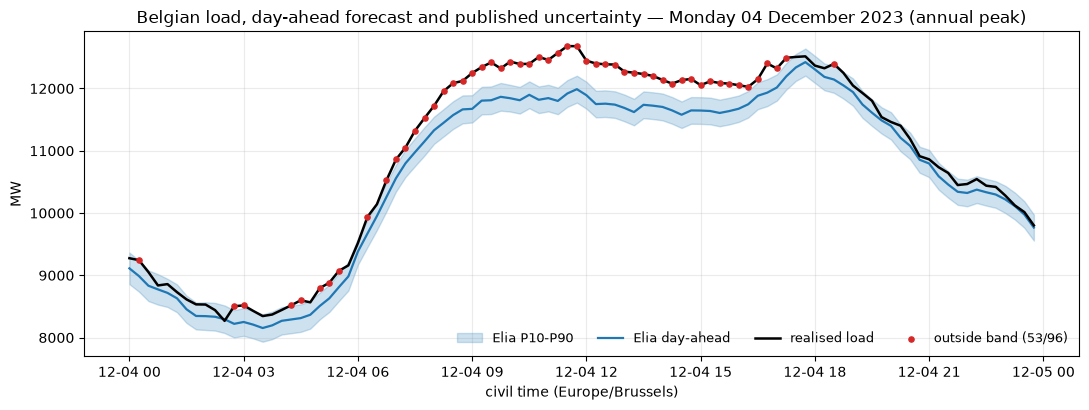

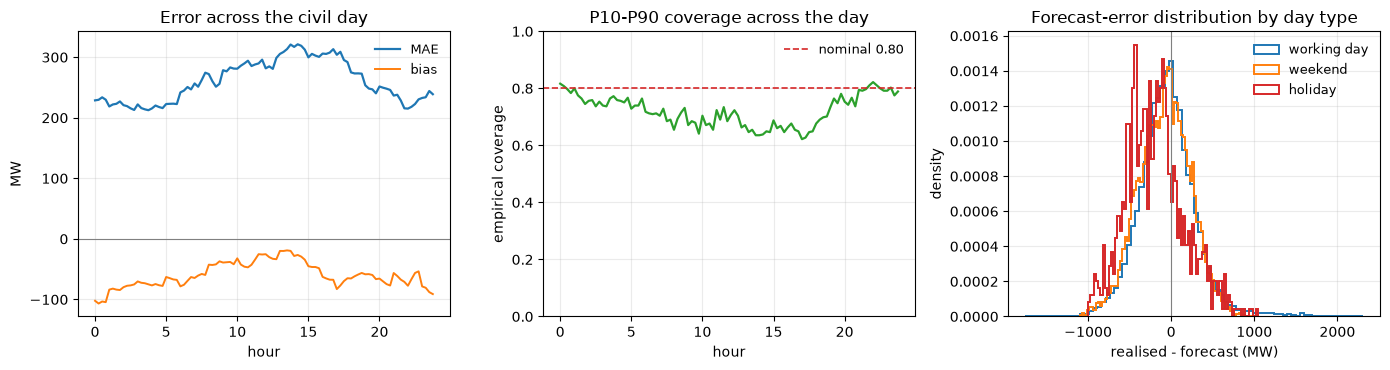

annual peak day: 2023-12-04  peak = 12,681 MW
widest band day: 2023-12-29


In [5]:
# CELL 07 · §3 · figures — Elia load, error and interval anatomy
# One day in full, then the shape of the error and the band across the day.

peak_day = A.loc[A["y"].idxmax(), "civil_date"]
d = A[A["civil_date"] == peak_day].copy()
d["t"] = d["datetime"].dt.tz_convert(TZ)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(d["t"], d["q10_da"], d["q90_da"], alpha=.22, color="tab:blue",
                label="Elia P10-P90")
ax.plot(d["t"], d["yhat_da"], color="tab:blue", lw=1.6, label="Elia day-ahead")
ax.plot(d["t"], d["y"], color="black", lw=1.8, label="realised load")
out = d[~d["inside"]]
ax.scatter(out["t"], out["y"], s=14, color="tab:red", zorder=5,
           label=f"outside band ({len(out)}/{len(d)})")
ax.set(title=f"Belgian load, day-ahead forecast and published uncertainty — "
             f"{peak_day:%A %d %B %Y} (annual peak)",
       xlabel=f"civil time ({TZ})", ylabel="MW")
ax.legend(frameon=False, ncol=4, fontsize=9); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

q = A.groupby("qod").agg(mae=("e", lambda s: s.abs().mean()),
                         bias=("e", "mean"))
axes[0].plot(q.index / 4, q["mae"], color="tab:blue", lw=1.6, label="MAE")
axes[0].plot(q.index / 4, q["bias"], color="tab:orange", lw=1.4, label="bias")
axes[0].axhline(0, color="grey", lw=.8)
axes[0].set(title="Error across the civil day", xlabel="hour", ylabel="MW")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)

c = A.groupby("qod")["inside"].mean()
axes[1].plot(c.index / 4, c, color="tab:green", lw=1.6)
axes[1].axhline(.80, color="tab:red", ls="--", lw=1.2, label="nominal 0.80")
axes[1].set(title="P10-P90 coverage across the day", xlabel="hour",
            ylabel="empirical coverage", ylim=(0, 1))
axes[1].legend(frameon=False, fontsize=9); axes[1].grid(alpha=.25)

for dt, col in [("working day", "tab:blue"), ("weekend", "tab:orange"),
                ("holiday", "tab:red")]:
    s = A[A["daytype"] == dt]
    if len(s):
        axes[2].hist(s["e"], bins=80, histtype="step", density=True,
                     color=col, lw=1.4, label=dt)
axes[2].axvline(0, color="grey", lw=.8)
axes[2].set(title="Forecast-error distribution by day type", xlabel="realised - forecast (MW)",
            ylabel="density")
axes[2].legend(frameon=False, fontsize=9); axes[2].grid(alpha=.25)

plt.tight_layout(); plt.show()

print(f"annual peak day: {peak_day:%Y-%m-%d}  peak = {A['y'].max():,.0f} MW")
print(f"widest band day: {A.groupby('civil_date').apply(lambda g: (g.q90_da - g.q10_da).mean()).idxmax():%Y-%m-%d}")


In [6]:
# CELL 08 · §4 · spectral preparation — uniform UTC grid
# The FFT needs a uniform grid with no holes. Three realised-load slots are
# missing, so they are filled — deliberately, and twice by unrelated means, so
# that any spectral conclusion can be shown not to rest on the interpolation.
# A run longer than one hour would raise instead of being smoothed over.

FS = 96.0                                   # samples per day on the UTC axis

Y_LIN, FILLED = fill_short_gaps(L["y"].to_numpy(), max_gap=4, method="linear")
Y_WK,  _      = fill_short_gaps(L["y"].to_numpy(), max_gap=4, method="weekly")

gaps = L.loc[FILLED, ["datetime", "civil_date", "qod"]].copy()
gaps["linear"] = Y_LIN[FILLED]
gaps["weekly"] = Y_WK[FILLED]
gaps["diff_MW"] = gaps["linear"] - gaps["weekly"]

print(f"filled {int(FILLED.sum())} of {len(L)} slots "
      f"({FILLED.sum() / len(L):.4%} of the series)")
print(gaps.to_string(index=False))
print(f"\nlargest disagreement between the two fills: "
      f"{gaps['diff_MW'].abs().max():.1f} MW")
print(f"series std: {np.nanstd(L['y']):.1f} MW — the fills differ by a small "
      f"fraction of one standard deviation, on 3 of {len(L)} points")


filled 3 of 35040 slots (0.0086% of the series)
                 datetime civil_date  qod    linear  weekly  diff_MW
2023-08-10 09:00:00+00:00 2023-08-10   44  8787.545 8688.15   99.395
2023-08-11 09:00:00+00:00 2023-08-11   44  9148.695 8803.79  344.905
2023-09-11 09:00:00+00:00 2023-09-11   44 11141.125 9731.21 1409.915

largest disagreement between the two fills: 1409.9 MW
series std: 1353.1 MW — the fills differ by a small fraction of one standard deviation, on 3 of 35040 points


In [7]:
# CELL 09 · §4 · periodogram and dominant historical periods
# Peaks are located by prominence on the log spectrum. No daily or weekly
# frequency is supplied in advance, so whatever appears is what the series has.
# Two cross-checks follow the house rule that a result is certified, not
# asserted: the spectrum is recomputed on the independent weekly fill, and
# without the Hann window.

FRQ, PSD = periodogram(Y_LIN, FS)                       # detrended, Hann
PEAKS = dominant_periods(FRQ, PSD, n_peaks=12, min_period_h=1.0)

PEAKS["period"] = np.where(PEAKS["period_d"] >= 1.5,
                           PEAKS["period_d"].round(2).astype(str) + " d",
                           PEAKS["period_h"].round(2).astype(str) + " h")

def structural(df, min_share=1e-3):
    """Components carrying at least 0.1% of the resolved density. Below that
    the peaks are at noise level and nothing should be built on them."""
    return np.sort(df.loc[df["share"] >= min_share, "period_h"].to_numpy())

REF = structural(PEAKS)
print("dominant spectral components — ranked by power, periods read off after")
print(PEAKS[["freq_cpd", "period", "psd", "share"]].to_string(index=False))
print(f"\n{len(REF)} of them carry >= 0.1% of the resolved density; the rest "
      f"sit at noise level and justify nothing")

# --- cross-checks: the structure must not depend on how it was computed ----
def agrees(other, tol=0.02):
    o = structural(other)
    return bool(len(o) == len(REF) and np.all(np.isclose(o, REF, rtol=tol)))

p_wk = dominant_periods(*periodogram(Y_WK, FS), n_peaks=12, min_period_h=1.0)
p_box = dominant_periods(*periodogram(Y_LIN, FS, window=None), n_peaks=12,
                         min_period_h=1.0)
print(f"\nindependent weekly gap fill  -> same components: {agrees(p_wk)}")
print(f"no window (leakage unmitigated) -> same components: {agrees(p_box)}")

# --- what the resolution allows to be said ---------------------------------
n = len(Y_LIN)
df_cpd = FS / n                                          # bin width, cycles/day
print(f"\nfrequency resolution: {df_cpd:.5f} cycles/day  "
      f"(record length {n / FS:.0f} days)")
print(f"the daily cycle sits on bin {1.0 / df_cpd:.0f} exactly; "
      f"the weekly cycle at {1 / 7 / df_cpd:.2f} does not — it falls between "
      f"bins and its power is spread over neighbours")
print(f"anything slower than {1 / df_cpd:.0f} days, the annual cycle included, "
      f"is unresolvable in a one-year record and is absorbed by the detrending")


dominant spectral components — ranked by power, periods read off after
 freq_cpd  period          psd    share
 1.000000  24.0 h 1.189207e+08 0.232127
 0.142466  7.02 d 3.639269e+07 0.071037
 2.000000  12.0 h 2.804351e+07 0.054739
 0.013699  73.0 d 1.502581e+07 0.029330
 0.284932  3.51 d 9.951685e+06 0.019425
 0.857534 27.99 h 3.399593e+06 0.006636
 0.715068 33.56 h 2.228216e+06 0.004349
 0.049315 20.28 d 1.928464e+06 0.003764
 0.030137 33.18 d 1.909773e+06 0.003728
 1.142466 21.01 h 1.726904e+06 0.003371
 0.065753 15.21 d 1.499809e+06 0.002928
 0.991781  24.2 h 7.765599e+05 0.001516

12 of them carry >= 0.1% of the resolved density; the rest sit at noise level and justify nothing

independent weekly gap fill  -> same components: True
no window (leakage unmitigated) -> same components: False

frequency resolution: 0.00274 cycles/day  (record length 365 days)
the daily cycle sits on bin 365 exactly; the weekly cycle at 52.14 does not — it falls between bins and its power is spread over 

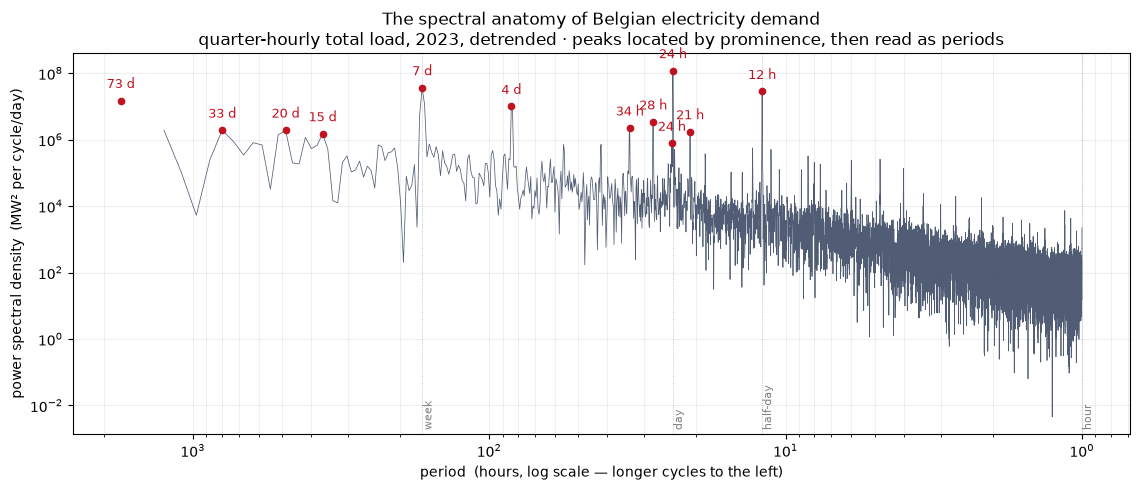

12 structural components carry 43.3% of the density in the resolved band


In [8]:
# CELL 10 · §4 · figure — spectral anatomy
per_h = np.divide(24.0, FRQ, out=np.full_like(FRQ, np.inf), where=FRQ > 0)
m = (per_h >= 1.0) & (per_h <= 24 * 60)

fig, ax = plt.subplots(figsize=(11.5, 5.0))
ax.plot(per_h[m], PSD[m], lw=.55, color="#33415c", alpha=.85)
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()                                   # long cycles on the left

for _, r in PEAKS[PEAKS["share"] >= 1e-3].iterrows():
    ax.plot(r["period_h"], r["psd"], "o", ms=4.5, color="#c1121f", zorder=5)
    lab = (f"{r['period_d']:.0f} d" if r["period_d"] >= 1.5
           else f"{r['period_h']:.0f} h")
    ax.annotate(lab, (r["period_h"], r["psd"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color="#c1121f")

for p, lab in [(24 * 7, "week"), (24, "day"), (12, "half-day"), (1, "hour")]:
    ax.axvline(p, color="grey", lw=.6, ls=":", alpha=.6)
    ax.text(p, ax.get_ylim()[0], f" {lab}", rotation=90, va="bottom",
            fontsize=8, color="grey")

ax.set(xlabel="period  (hours, log scale — longer cycles to the left)",
       ylabel="power spectral density  (MW² per cycle/day)",
       title="The spectral anatomy of Belgian electricity demand\n"
             "quarter-hourly total load, 2023, detrended · peaks located by "
             "prominence, then read as periods")
ax.grid(alpha=.2, which="both")
plt.tight_layout()
plt.savefig("../figures/spectral_anatomy.png", dpi=200, bbox_inches="tight")
plt.show()

carried = PEAKS.loc[PEAKS["share"] >= 1e-3, "share"].sum()
print(f"{int((PEAKS['share'] >= 1e-3).sum())} structural components carry "
      f"{carried:.1%} of the density in the resolved band")


<div class="phnx-card"><div class="phnx-cell">CELL 11</div><h2>§4 · What the spectrum does and does not license</h2>
<p>A periodogram is a variance decomposition, not a forecast. Strong daily and weekly peaks show that recurring temporal structure is real, but they do not establish out-of-sample predictability. The full-year spectrum is therefore descriptive only and is <strong>not</strong> used to choose predictive frequencies.</p>
<p>One civil year also has finite spectral resolution. Daily harmonics align naturally with the calendar; a weekly cycle need not land exactly on a Fourier bin, and an annual cycle cannot be identified from a single annual period. These limits motivate a small calendar-defined Fourier basis rather than peak-shopping.</p>
</div>

In [9]:
# CELL 12 · §5 · civil-time persistence baselines
# Two transparent baselines: the same clock time yesterday, and the same clock
# time last week. Matched on the civil key rather than by shifting 96 or 672
# rows, because the civil day holds 92 or 100 quarters at the transitions and a
# fixed row offset would quietly reuse the wrong hour twice a year.
#
# The baselines need history from before the analysis window. Without a warm-up
# the first week of January has no previous-week forecast at all — and January
# is where Elia's own bias is largest, so dropping it would tilt the comparison.
# The cached pull already spans a month either side, so the warm-up is free.

WARMUP = pd.Timedelta(days=14)
LH, dropped_hist = complete_civil_days(S, START - WARMUP, END, TZ, FREQ)
LH["is_holiday"] = LH["civil_date"].isin(be_holidays(sorted({*LH["civil_date"].dt.year})))
print(f"history frame: {len(LH)} slots, {LH['civil_date'].nunique()} civil days, "
      f"{LH['civil_date'].min():%Y-%m-%d} .. {LH['civil_date'].max():%Y-%m-%d}")

BASELINES = {"pd1": ("previous day (D-1)", 1),
             "pw7": ("previous week (D-7)", 7)}

for col, (label, lag) in BASELINES.items():
    b = seasonal_naive(LH, lag)
    LH[col] = b["yhat"]
    LH[f"{col}_src"] = b["source_time"]

# Evaluation is restricted to the analysis window; the warm-up only feeds it.
B = LH[LH["civil_date"].between(START, END)].reset_index(drop=True)
B["daytype"] = np.where(B["is_holiday"], "holiday",
                np.where(B["is_weekend"], "weekend", "working day"))

print(f"\nevaluation frame: {len(B)} slots over {B['civil_date'].nunique()} civil days")
for col, (label, _) in BASELINES.items():
    na = B[col].isna()
    print(f"  {label:22s} unavailable {int(na.sum()):3d}")
    if na.any():
        print(B.loc[na, ["datetime", "civil_date", "qod"]]
                .assign(reason=np.where(B.loc[na, "qod"].between(8, 11),
                                        "spring-forward gap in source",
                                        "source observation missing"))
                .to_string(index=False))
print(f"\nmissing target load in the window: {int(B['y'].isna().sum())} "
      f"— availability of a forecast and presence of a target are separate")


history frame: 36384 slots, 379 civil days, 2022-12-18 .. 2023-12-31

evaluation frame: 35040 slots over 365 civil days
  previous day (D-1)     unavailable   7
                 datetime civil_date  qod                       reason
2023-03-27 00:00:00+00:00 2023-03-27    8 spring-forward gap in source
2023-03-27 00:15:00+00:00 2023-03-27    9 spring-forward gap in source
2023-03-27 00:30:00+00:00 2023-03-27   10 spring-forward gap in source
2023-03-27 00:45:00+00:00 2023-03-27   11 spring-forward gap in source
2023-08-11 09:00:00+00:00 2023-08-11   44   source observation missing
2023-08-12 09:00:00+00:00 2023-08-12   44   source observation missing
2023-09-12 09:00:00+00:00 2023-09-12   44   source observation missing
  previous week (D-7)    unavailable   7
                 datetime civil_date  qod                       reason
2023-04-02 00:00:00+00:00 2023-04-02    8 spring-forward gap in source
2023-04-02 00:15:00+00:00 2023-04-02    9 spring-forward gap in source
2023-04-02 00:30:

In [10]:
# CELL 13 · §5 · origin audit for persistence baselines
# The origin is 18:00 civil on D-1: the ODS001 schema identifies this column as
# the Day-ahead 6PM forecast (see CELL 01). Every value a forecast uses must
# predate it. This is checked, not asserted — and one baseline does not pass.

ORIGIN = daily_origin(B["civil_date"], ORIGIN_CIVIL_HOUR, lead_days=1, tz=TZ)
VIOL = {}
for col, (label, _) in BASELINES.items():
    v = origin_violations(B[f"{col}_src"], ORIGIN)
    VIOL[col] = v
    tail = f", worst {v['late_by'].max()} after the origin" if len(v) else ""
    print(f"{label:22s} source values after origin: {len(v):6d} of {len(B)}{tail}")

late = len(VIOL["pd1"])
print(f"\nD-1 draws on the evening of the source day, which postdates an 18:00 "
      f"origin: {late} of {len(B)} values ({late / len(B):.0%}).")
print("It is therefore an INFORMED baseline, admissible only under an origin at "
      "the day boundary. D-7 is clean at the stated origin and is the "
      "operational baseline.")

# --- robustness: would an earlier operational origin change the reading? ----
# Elia's general load documentation has quoted other update times. Those do not
# describe this column, but running the audit at each shows the conclusion does
# not rest on the choice.
print("\n--- robustness to alternative published issue times ---")
rows = []
for name, hour in ORIGIN_CANDIDATES.items():
    o = daily_origin(B["civil_date"], hour, lead_days=1, tz=TZ)
    r = {"origin": name}
    for col, (label, _) in BASELINES.items():
        v = origin_violations(B[f"{col}_src"], o)
        r[f"{label} violations"] = len(v)
        r[f"{label} worst"] = str(v["late_by"].max()) if len(v) else "-"
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))
print("\nD-7 is leakage-free under every candidate origin, while D-1 is at least "
      "partly informed under all of them. The operational reading is therefore "
      "robust to the alternative publication-time documentation.")


previous day (D-1)     source values after origin:   8395 of 35040, worst 0 days 05:45:00 after the origin
previous week (D-7)    source values after origin:      0 of 35040

D-1 draws on the evening of the source day, which postdates an 18:00 origin: 8395 of 35040 values (24%).
It is therefore an INFORMED baseline, admissible only under an origin at the day boundary. D-7 is clean at the stated origin and is the operational baseline.

--- robustness to alternative published issue times ---
                                  origin  previous day (D-1) violations previous day (D-1) worst  previous week (D-7) violations previous week (D-7) worst
08:45 (Elia load page, earlier revision)                          21900          0 days 15:00:00                               0                         -
         12:00 (Elia load page, current)                          17155          0 days 11:45:00                               0                         -
         18:00 (ODS001 schema — primary)

In [11]:
# CELL 14 · §5 · common-sample baseline evaluation
# Metrics computed over different timestamp sets are not comparable, so every
# model is scored on the slots where all of them exist.

MODELS = {"pd1": "previous day (D-1)", "pw7": "previous week (D-7)",
          "yhat_da": "Elia day-ahead"}

COMMON = B.dropna(subset=["y", *MODELS]).copy()
print(f"common sample: {len(COMMON)} of {len(B)} slots "
      f"({len(B) - len(COMMON)} dropped for a missing target or forecast)")

POINT = pd.DataFrame([score_point(COMMON, y="y", yhat=c).rename(lab)
                      for c, lab in MODELS.items()])[["n_point", "bias", "MAE", "RMSE"]]
print("\npoint accuracy on the common sample, 2023 (MW; error = actual - forecast)")
print(POINT.round(1).to_string())

ref = POINT.loc["previous week (D-7)", "MAE"]
print(f"\nMAE relative to the previous-week baseline:")
for lab, r in POINT.iterrows():
    print(f"  {lab:22s} {r['MAE']:7.1f}   {100 * (1 - r['MAE'] / ref):+6.1f}%")

def by_col(key, label=None):
    t = pd.DataFrame({lab: COMMON.groupby(key)
                              .apply(lambda g: score_point(g, y="y", yhat=c)["MAE"])
                      for c, lab in MODELS.items()})
    print(f"\n--- MAE by {label or key} (MW) ---")
    print(t.round(1).to_string())
    return t

by_daytype = by_col("daytype", "day type")
by_dow     = by_col("dow", "weekday (0 = Monday)")
by_hourly  = by_col("hour", "civil hour")


common sample: 35024 of 35040 slots (16 dropped for a missing target or forecast)

point accuracy on the common sample, 2023 (MW; error = actual - forecast)
                     n_point  bias    MAE   RMSE
previous day (D-1)   35024.0  -0.3  482.3  706.1
previous week (D-7)  35024.0  -4.2  433.8  594.9
Elia day-ahead       35024.0 -59.9  259.9  342.0

MAE relative to the previous-week baseline:
  previous day (D-1)       482.3    -11.2%
  previous week (D-7)      433.8     +0.0%
  Elia day-ahead           259.9    +40.1%

--- MAE by day type (MW) ---
             previous day (D-1)  previous week (D-7)  Elia day-ahead
daytype                                                             
holiday                   656.2               1310.4           329.0
weekend                   596.4                383.6           254.9
working day               428.8                419.4           259.2

--- MAE by weekday (0 = Monday) (MW) ---
     previous day (D-1)  previous week (D-7)  Elia day-a

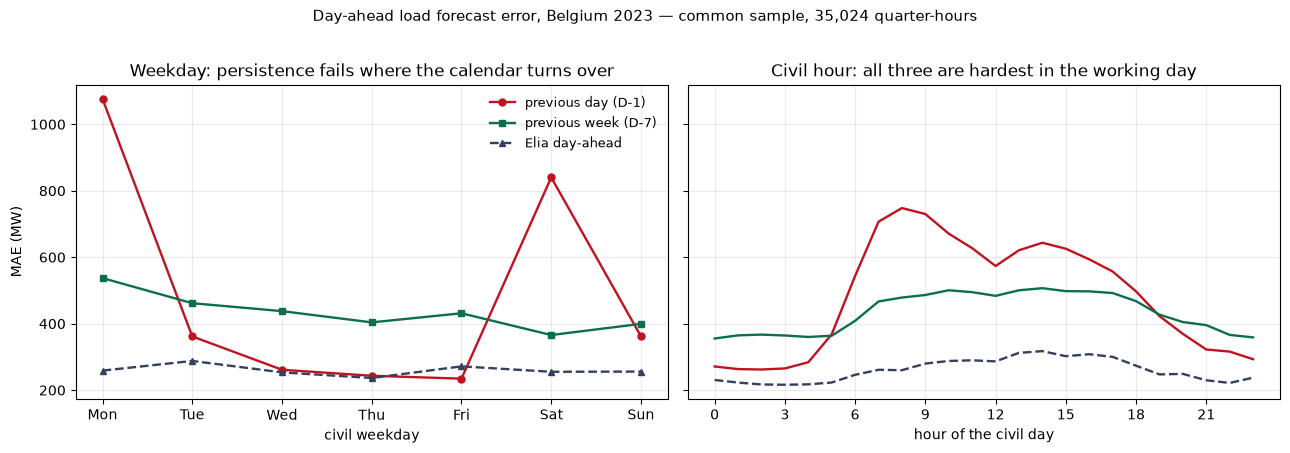

In [12]:
# CELL 15 · §5 · figure — persistence error anatomy
# Not another time series: the two panels that carry the finding. Weekday shows
# why matching the calendar beats matching the clock; hour shows that both fail
# in the same part of the day.

STYLE = {"previous day (D-1)": ("#c1121f", "-", "o"),
         "previous week (D-7)": ("#0b6e4f", "-", "s"),
         "Elia day-ahead": ("#33415c", "--", "^")}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)

for lab, (col, ls, mk) in STYLE.items():
    axes[0].plot(by_dow.index, by_dow[lab], color=col, ls=ls, marker=mk, ms=5, lw=1.7,
                 label=lab)
axes[0].set(title="Weekday: persistence fails where the calendar turns over",
            xlabel="civil weekday", ylabel="MAE (MW)")
axes[0].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=.25)

for lab, (col, ls, mk) in STYLE.items():
    axes[1].plot(by_hourly.index, by_hourly[lab], color=col, ls=ls, lw=1.7, label=lab)
axes[1].set(title="Civil hour: all three are hardest in the working day",
            xlabel="hour of the civil day")
axes[1].set_xticks(range(0, 24, 3))
axes[1].grid(alpha=.25)

fig.suptitle("Day-ahead load forecast error, Belgium 2023 — common sample, "
             f"{len(COMMON):,} quarter-hours", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("../figures/baseline_error.png", dpi=200, bbox_inches="tight")
plt.show()


<div class="phnx-card"><div class="phnx-cell">CELL 16</div><h2>§5 · Transparent persistence benchmarks</h2>
<p>Previous-day and previous-week persistence are aligned by Belgian civil clock, not by fixed UTC row shifts. The previous-week forecast is the clean operational baseline at the 18:00 D−1 origin; previous-day persistence is partly informed by observations that occur after that origin and is retained only as a descriptive comparator.</p>
<p>The previous-week benchmark often beats previous-day persistence because load follows the weekly calendar. Holidays are the obvious failure mode: the same weekday one week earlier is usually an ordinary working day.</p>
</div>

In [13]:
# CELL 17 · §6 · Fourier/calendar model — rolling and expanding fits
# The model is written down before it is estimated, and never searched over.
# Harmonic counts are the first K harmonics of the day and the week — periods
# that follow from the calendar. They are NOT read off the §4 spectrum: that
# periodogram was estimated on the whole of 2023, so choosing frequencies from
# it would leak the evaluation period into the specification.

print("model:", SPEC.describe())
print(f"design columns: {design_matrix(LH.head(1)).shape[1]}")
print("\nno annual harmonic: with about a month of history before the evaluation "
      "window\nbegins, a yearly cycle is not identifiable and fitting one would "
      "extrapolate\na period the data cannot support. Seasonal level is carried by "
      "the estimation\nwindow instead, and both protocols are reported so that "
      "choice stays visible.")

PROTOCOLS = {"fourier_roll": ("Fourier+calendar, 56-day window", 56),
             "fourier_exp":  ("Fourier+calendar, expanding",     None)}

for col, (label, window) in PROTOCOLS.items():
    fit = forecast_by_origin(LH, targets=B["civil_date"].unique(), spec=SPEC,
                             origin_civil_hour=ORIGIN_CIVIL_HOUR, lead_days=1,
                             tz=TZ, window_days=window, min_history_days=28)
    LH[col] = fit["yhat"]
    if col == "fourier_roll":
        FIT = fit
    print(f"\n{label}: {int(fit['available'].sum())} of {len(LH)} slots forecast")

B = LH[LH["civil_date"].between(START, END)].reset_index(drop=True)
B["daytype"] = np.where(B["is_holiday"], "holiday",
                np.where(B["is_weekend"], "weekend", "working day"))
for col, (label, _) in PROTOCOLS.items():
    na = B[col].isna()
    print(f"{label:34s} unavailable in 2023: {int(na.sum()):4d}"
          + (f"  (first {B.loc[na, 'civil_date'].min():%Y-%m-%d}, "
             f"last {B.loc[na, 'civil_date'].max():%Y-%m-%d})" if na.any() else ""))


model: daily harmonics 24h, 12h, 8h, 6h estimated separately for working and non-working days; weekly harmonics 168h, 84h, 56h; intercept and a non-working level term; ordinary least squares
design columns: 24

no annual harmonic: with about a month of history before the evaluation window
begins, a yearly cycle is not identifiable and fitting one would extrapolate
a period the data cannot support. Seasonal level is carried by the estimation
window instead, and both protocols are reported so that choice stays visible.

Fourier+calendar, 56-day window: 33600 of 36384 slots forecast

Fourier+calendar, expanding: 33600 of 36384 slots forecast
Fourier+calendar, 56-day window    unavailable in 2023: 1440  (first 2023-01-01, last 2023-01-15)
Fourier+calendar, expanding        unavailable in 2023: 1440  (first 2023-01-01, last 2023-01-15)


In [14]:
# CELL 18 · §6 · temporal-integrity audit of Fourier fits
# A model refit per day is exposed to a failure the baselines are not: the fit
# window quietly including the day it is asked to predict. Checked here on the
# real run, not only in the unit tests.

A_FIT = FIT.loc[FIT["available"]]
tgt_start = (LH.loc[FIT["available"], ["civil_date"]]
               .assign(t=LH.loc[FIT["available"], "datetime"])
               .groupby("civil_date")["t"].transform("min"))

print(f"fitted days: {A_FIT['origin'].nunique()}")
print(f"fit window ends after its origin:      "
      f"{int((A_FIT['fit_end'] > A_FIT['origin']).sum())}")
print(f"fit window reaches its own target day: "
      f"{int((A_FIT['fit_end'] >= tgt_start).sum())}")
print(f"rows used per fit: {A_FIT['n_fit'].min():.0f} .. {A_FIT['n_fit'].max():.0f} "
      f"(56 days = {56 * 96} slots)")
print(f"worst gap between fit end and target start: "
      f"{(tgt_start - A_FIT['fit_end']).min()}")

assert (A_FIT["fit_end"] <= A_FIT["origin"]).all(), "fit window crosses the origin"
assert (A_FIT["fit_end"] < tgt_start).all(), "fit window reaches the target day"
print("\ntemporal integrity holds on the real run for every fitted day")


fitted days: 350
fit window ends after its origin:      0
fit window reaches its own target day: 0
rows used per fit: 2761 .. 5376 (56 days = 5376 slots)
worst gap between fit end and target start: 0 days 06:00:00

temporal integrity holds on the real run for every fitted day


In [15]:
# CELL 19 · §6 · common-sample Fourier evaluation + decomposition
MODELS6 = {"pw7": "previous week (D-7)",
           "fourier_roll": "Fourier+calendar (56d)",
           "fourier_exp": "Fourier+calendar (expanding)",
           "yhat_da": "Elia day-ahead"}

COMMON6 = B.dropna(subset=["y", *MODELS6]).copy()
print(f"common sample: {len(COMMON6)} of {len(B)} slots "
      f"({len(B) - len(COMMON6)} dropped for a missing target or forecast)")

POINT6 = pd.DataFrame([score_point(COMMON6, y="y", yhat=c).rename(lab)
                       for c, lab in MODELS6.items()])[["n_point", "bias", "MAE", "RMSE"]]
ref = POINT6.loc["previous week (D-7)", "MAE"]
POINT6["vs D-7 %"] = 100 * (1 - POINT6["MAE"] / ref)
print("\npoint accuracy on the common sample (MW; error = actual - forecast)")
print(POINT6.round(1).to_string())

def by6(key, label=None):
    t = pd.DataFrame({lab: COMMON6.groupby(key)
                              .apply(lambda g: score_point(g, y="y", yhat=c)["MAE"])
                      for c, lab in MODELS6.items()})
    print(f"\n--- MAE by {label or key} (MW) ---")
    print(t.round(1).to_string())
    return t

# --- where the error lives: the level of the day, or its shape? ------------
# Attribution, not a model change. Each error is split into the mean error over
# its target civil day and the remainder within the day. If a forecast has the
# shape right but the level wrong, the first term dominates — and that is a
# different deficiency, with a different remedy, from getting the shape wrong.
print("\n--- error decomposition, MAE (MW) ---")
rows = []
for col, lab in MODELS6.items():
    e = COMMON6["y"] - COMMON6[col]
    level = e.groupby(COMMON6["civil_date"]).transform("mean")
    rows.append({"model": lab, "MAE": e.abs().mean(),
                 "day-level": level.abs().mean(),
                 "within-day shape": (e - level).abs().mean(),
                 "level share of var": level.var() / e.var()})
print(pd.DataFrame(rows).set_index("model").round(2).to_string())

by6_daytype = by6("daytype", "day type")
by6_hour    = by6("hour", "civil hour")


common sample: 33590 of 35040 slots (1450 dropped for a missing target or forecast)

point accuracy on the common sample (MW; error = actual - forecast)
                              n_point   bias    MAE   RMSE  vs D-7 %
previous week (D-7)           33590.0  -35.7  418.7  578.5       0.0
Fourier+calendar (56d)        33590.0   23.7  558.8  691.5     -33.4
Fourier+calendar (expanding)  33590.0 -259.7  728.9  887.3     -74.1
Elia day-ahead                33590.0  -66.7  257.9  339.5      38.4

--- error decomposition, MAE (MW) ---
                                 MAE  day-level  within-day shape  level share of var
model                                                                                
previous week (D-7)           418.73     370.16            206.91                0.76
Fourier+calendar (56d)        558.78     530.41            191.83                0.87
Fourier+calendar (expanding)  728.89     703.87            222.66                0.89
Elia day-ahead                257

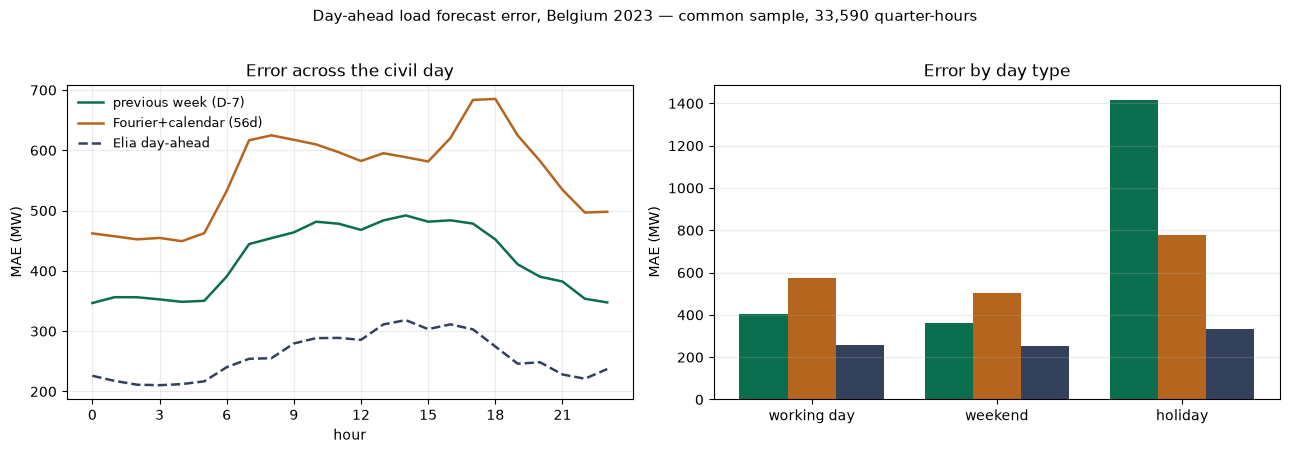

In [16]:
# CELL 20 · §6 · figure — Fourier error anatomy
SHOW = ["previous week (D-7)", "Fourier+calendar (56d)", "Elia day-ahead"]
COLOUR = {"previous week (D-7)": "#0b6e4f", "Fourier+calendar (56d)": "#b5651d",
          "Elia day-ahead": "#33415c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for lab in SHOW:
    axes[0].plot(by6_hour.index, by6_hour[lab], color=COLOUR[lab], lw=1.8,
                 ls="--" if lab == "Elia day-ahead" else "-", label=lab)
axes[0].set(title="Error across the civil day", xlabel="hour", ylabel="MAE (MW)")
axes[0].set_xticks(range(0, 24, 3)); axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=.25)

order = ["working day", "weekend", "holiday"]
x = np.arange(len(order)); w = 0.26
for i, lab in enumerate(SHOW):
    axes[1].bar(x + (i - 1) * w, by6_daytype.loc[order, lab], w,
                color=COLOUR[lab], label=lab)
axes[1].set(title="Error by day type", ylabel="MAE (MW)")
axes[1].set_xticks(x, order); axes[1].grid(alpha=.25, axis="y")

fig.suptitle("Day-ahead load forecast error, Belgium 2023 — common sample, "
             f"{len(COMMON6):,} quarter-hours", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fourier_error.png", dpi=200, bbox_inches="tight")
plt.show()


<div class="phnx-card"><div class="phnx-cell">CELL 21</div><h2>§6 · Frozen Fourier/calendar model</h2>
<p>The basis is specified from calendar logic, not from future spectral peaks: four daily harmonics, three weekly harmonics, separate working/non-working daily shapes, an intercept and a non-working level term. A 56-day rolling ordinary-least-squares fit is the primary specification; the expanding fit is a diagnostic.</p>
<p>The model's 2023 failure is informative: it captures recurring intraday shape better than its overall MAE suggests, while missing target-day level. A numerical audit of representative rolling design matrices is retained to distinguish information limitations from numerical instability.</p>
</div>

In [17]:
# CELL 22 · §6 · Fourier-basis numerical audit
# Representative 56-day design matrices across the later evaluation year.
# This is an identifiability/conditioning audit, not a model-selection step.
audit_days = pd.to_datetime(["2024-01-15", "2024-04-15", "2024-07-15", "2024-10-15"])
audit_rows = []

# If C24 is not built yet, use the development/history frame for an equivalent
# design audit where possible; the 2024 audit is repeated after C24 is created.
source_for_audit = LH
for target_day in audit_days:
    origin = daily_origin([target_day], ORIGIN_CIVIL_HOUR, 1, TZ).iloc[0]
    m = (
        (source_for_audit["datetime"] <= origin)
        & (source_for_audit["datetime"] > origin - pd.Timedelta(days=56))
    )
    if not m.any():
        continue
    X = design_matrix(source_for_audit.loc[m])
    s = np.linalg.svd(np.asarray(X, dtype=float), compute_uv=False)
    rank = int(np.linalg.matrix_rank(np.asarray(X, dtype=float)))
    audit_rows.append({
        "target_day": target_day.date(),
        "n_rows": len(X),
        "n_columns": X.shape[1],
        "rank": rank,
        "rank_deficiency": X.shape[1] - rank,
        "smallest_sv": s.min(),
        "largest_sv": s.max(),
        "condition_number": s.max() / s.min(),
    })

fourier_numerical_audit = pd.DataFrame(audit_rows)
if len(fourier_numerical_audit):
    display(fourier_numerical_audit.round(3))
    assert (fourier_numerical_audit["rank_deficiency"] == 0).all()
    assert np.isfinite(fourier_numerical_audit["condition_number"]).all()
    print("PASS — audited Fourier/calendar designs are full-rank and finite-conditioned.")
else:
    print("2024 representative windows are not yet present; audit repeats after confirmation data are built.")


,target_day,n_rows,n_columns,rank,rank_deficiency,smallest_sv,largest_sv,condition_number
0,2024-01-15,4055,24,24,0,10.927,68.08,6.231


PASS — audited Fourier/calendar designs are full-rank and finite-conditioned.


<div class="phnx-card phnx-freeze"><div class="phnx-cell">CELL 23</div><h2>§7 · Leakage-safe recent-level correction</h2>
<p>The frozen Fourier shape receives one scalar additive correction estimated from realised errors of <em>previously issued</em> Fourier forecasts over the last 24 elapsed hours available at the target origin. The same scalar is applied to every target slot, so shape is unchanged.</p>
<p>The 24-hour window is a pre-specified information choice, not a tuned hyperparameter. Two controls are required: a negative control proving that post-origin actuals cannot change an issued forecast, and a positive control proving that permitted pre-origin information changes the forecast by the amount implied by the arithmetic.</p>
</div>

In [18]:
# CELL 24 · §7 · recent-level correction + 2023 evaluation
from electricity_load_forecasting.level import recent_residual_level_correction

# Evaluate only the civil dates in the established evaluation period.
target_dates = (
    LH.loc[LH["civil_date"].between(START, END), "civil_date"]
    .drop_duplicates()
    .to_numpy()
)

LEVEL = recent_residual_level_correction(
    LH,
    base_forecast=LH["fourier_roll"],
    targets=target_dates,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)

# Same scalar level correction is added to every slot of a target day.
LH["fourier_level"] = LEVEL["yhat"]


# ── Temporal-integrity audit ─────────────────────────────────────────────

A_LEVEL = LEVEL.loc[LEVEL["available"]].copy()

print("recent-level correction")
print(f"forecast slots: {len(A_LEVEL)}")
print(f"target days:    {A_LEVEL['origin'].nunique()}")

if len(A_LEVEL):
    print(
        "recent errors used per origin: "
        f"{A_LEVEL['n_level'].min():.0f} .. "
        f"{A_LEVEL['n_level'].max():.0f}"
    )

    n_after_origin = int(
        (A_LEVEL["level_end"] > A_LEVEL["origin"]).sum()
    )
    print(f"level windows ending after origin: {n_after_origin}")

    assert n_after_origin == 0
    assert (A_LEVEL["level_end"] <= A_LEVEL["origin"]).all()


# ── Evaluation frame ─────────────────────────────────────────────────────

B7 = LH.loc[LH["civil_date"].between(START, END)].copy()

MODELS7 = {
    "pw7": "previous week (D-7)",
    "fourier_roll": "Fourier+calendar (56d)",
    "fourier_level": "Fourier+calendar + recent level",
    "yhat_da": "Elia day-ahead",
}

# Strict common sample: every model and the actual must be available.
COMMON7 = B7.dropna(
    subset=["y", *MODELS7.keys()]
).copy()


# ── Point-forecast comparison ────────────────────────────────────────────

rows = []

for col, label in MODELS7.items():
    s = score_point(COMMON7, y="y", yhat=col)

    rows.append(
        {
            "model": label,
            "n_point": s["n_point"],
            "bias": s["bias"],
            "MAE": s["MAE"],
            "RMSE": s["RMSE"],
        }
    )

POINT7 = pd.DataFrame(rows).set_index("model")

d7_mae = POINT7.loc["previous week (D-7)", "MAE"]

POINT7["vs D-7 %"] = (
    100.0 * (d7_mae - POINT7["MAE"]) / d7_mae
)

print(f"\ncommon sample: {len(COMMON7)} of {len(B7)} slots")
print("\npoint accuracy (MW; error = actual - forecast)")

display(
    POINT7.round(
        {
            "bias": 1,
            "MAE": 1,
            "RMSE": 1,
            "vs D-7 %": 1,
        }
    )
)


# ── Size of the estimated level corrections ──────────────────────────────

offsets = (
    A_LEVEL.groupby("origin")["level_offset"]
    .first()
    .dropna()
)

print("\nlevel correction itself")
print(f"number of corrected days: {len(offsets)}")
print(f"mean offset:          {offsets.mean():8.1f} MW")
print(f"median offset:        {offsets.median():8.1f} MW")
print(f"mean absolute offset: {offsets.abs().mean():8.1f} MW")
print(f"largest downward:     {offsets.min():8.1f} MW")
print(f"largest upward:       {offsets.max():8.1f} MW")


recent-level correction
forecast slots: 33504
target days:    349
recent errors used per origin: 73 .. 96
level windows ending after origin: 0

common sample: 33494 of 35040 slots

point accuracy (MW; error = actual - forecast)


,n_point,bias,MAE,RMSE,vs D-7 %
model,,,,,
previous week (D-7),33494.0,-36.7,419.1,579.0,0.0
Fourier+calendar (56d),33494.0,20.6,557.3,689.8,-33.0
Fourier+calendar + recent level,33494.0,-7.4,254.5,328.8,39.3
Elia day-ahead,33494.0,-67.3,258.0,339.6,38.4



level correction itself
number of corrected days: 349
mean offset:              27.9 MW
median offset:            22.2 MW
mean absolute offset:    528.9 MW
largest downward:      -1828.1 MW
largest upward:         1511.2 MW


In [19]:
# CELL 25 · §7 · positive control — permitted level information must move the forecast
# Positive information control: permitted pre-origin actuals must matter.
# Shifting every actual in the legitimate 24 h level window by +500 MW should
# move the estimated scalar offset — and therefore every target forecast — by
# exactly +500 MW.
check_day = pd.Timestamp("2023-07-15")
base_run = recent_residual_level_correction(
    LH, LH["fourier_roll"], targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR, lead_days=1, tz=TZ,
    window_hours=24, min_rows=48,
)
rows = base_run["available"]
assert rows.any()
origin = base_run.loc[rows, "origin"].iloc[0]

shifted = LH.copy()
inside = (
    (shifted["datetime"] <= origin)
    & (shifted["datetime"] > origin - pd.Timedelta(hours=24))
)
shifted.loc[inside, "y"] += 500.0

shift_run = recent_residual_level_correction(
    shifted, shifted["fourier_roll"], targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR, lead_days=1, tz=TZ,
    window_hours=24, min_rows=48,
)

delta_offset = (
    shift_run.loc[rows, "level_offset"].iloc[0]
    - base_run.loc[rows, "level_offset"].iloc[0]
)
delta_forecast = np.nanmax(
    shift_run.loc[rows, "yhat"].to_numpy()
    - base_run.loc[rows, "yhat"].to_numpy()
)
print(f"offset change:   {delta_offset:.6f} MW")
print(f"forecast change: {delta_forecast:.6f} MW")
assert np.isclose(delta_offset, 500.0)
assert np.isclose(delta_forecast, 500.0)
print("PASS — legitimate pre-origin information enters the level correction with the expected arithmetic effect.")


offset change:   500.000000 MW
forecast change: 500.000000 MW
PASS — legitimate pre-origin information enters the level correction with the expected arithmetic effect.


In [20]:
# CELL 26 · §7 · negative control — post-origin actuals cannot move the forecast
# ── Real-data leakage falsification ──────────────────────────────────────
# Changing information that becomes available only AFTER the forecast
# origin must not alter the forecast already issued for that target day.

check_day = pd.Timestamp("2023-07-15")

original = recent_residual_level_correction(
    LH,
    base_forecast=LH["fourier_roll"],
    targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)

# For this one requested target day, these are exactly its forecast rows.
mask = original["available"]

assert mask.any(), "No forecast rows were produced for the chosen target day."

origin = original.loc[mask, "origin"].iloc[0]

# Destroy every actual that becomes known only after the forecast origin.
tampered = LH.copy()
future = tampered["datetime"] > origin

tampered.loc[future, "y"] = (
    tampered.loc[future, "y"] + 1_000_000.0
)

changed = recent_residual_level_correction(
    tampered,
    base_forecast=tampered["fourier_roll"],
    targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)

a = original.loc[mask, "yhat"].to_numpy()
b = changed.loc[mask, "yhat"].to_numpy()

assert len(a) > 0
assert len(a) == len(b)

max_change = np.max(np.abs(a - b))

print(f"target day:              {check_day.date()}")
print(f"forecast origin:         {origin}")
print(f"target forecast slots:   {len(a)}")
print(f"future rows changed:     {future.sum()}")
print(f"maximum forecast change: {max_change:.12f} MW")

assert np.allclose(a, b, equal_nan=True)

print("PASS — post-origin actuals cannot affect the issued forecast.")


target day:              2023-07-15
forecast origin:         2023-07-14 16:00:00+00:00
target forecast slots:   96
future rows changed:     16347
maximum forecast change: 0.000000000000 MW
PASS — post-origin actuals cannot affect the issued forecast.


In [21]:
# CELL 27 · §7 · structural audit — every residual comes from a previously issued forecast
# ── Historical-forecast leakage audit ────────────────────────────────────
# The recent-level correction uses realised errors from earlier Fourier
# forecasts. Verify that those Fourier forecasts were themselves issued
# without looking beyond their own forecast origin.

check_day = pd.Timestamp("2023-07-15")

# Reuse the already verified target-day forecast origin.
original = recent_residual_level_correction(
    LH,
    base_forecast=LH["fourier_roll"],
    targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)

target_rows = original["available"]

assert target_rows.any()

target_origin = original.loc[target_rows, "origin"].iloc[0]
window_start = target_origin - pd.Timedelta(hours=24)

# These are exactly the historical actual/forecast pairs that could
# contribute to the recent-error level estimate.
used_mask = (
    (LH["datetime"] > window_start)
    & (LH["datetime"] <= target_origin)
    & LH["y"].notna()
    & LH["fourier_roll"].notna()
)

used = LH.loc[used_mask].copy()
audit = FIT.loc[used.index].copy()

# FIT was previously verified to be the audit frame corresponding
# exactly to LH["fourier_roll"].
assert np.allclose(
    audit["yhat"].to_numpy(),
    used["fourier_roll"].to_numpy(),
    equal_nan=True,
)

# 1. The model fit producing each historical Fourier forecast must
#    stop no later than its own stated forecast origin.
fit_after_own_origin = audit["fit_end"] > audit["origin"]

# 2. Each historical Fourier forecast must have been issued before
#    the observation whose realised error is subsequently used.
forecast_not_preexisting = (
    audit["origin"].to_numpy()
    >= used["datetime"].to_numpy()
)

print(f"target day:                         {check_day.date()}")
print(f"target origin:                      {target_origin}")
print(f"recent window start:                {window_start}")
print(f"historical residuals used:          {len(used)}")
print(f"latest realised observation used:   {used['datetime'].max()}")
print(f"fits ending after own origin:        {int(fit_after_own_origin.sum())}")
print(
    "forecasts not issued before observation: "
    f"{int(forecast_not_preexisting.sum())}"
)

assert len(used) >= 48
assert used["datetime"].max() <= target_origin
assert not fit_after_own_origin.any()
assert not forecast_not_preexisting.any()

print(
    "PASS — every level residual comes from a previously issued, "
    "leakage-safe Fourier forecast."
)


target day:                         2023-07-15
target origin:                      2023-07-14 16:00:00+00:00
recent window start:                2023-07-13 16:00:00+00:00
historical residuals used:          96
latest realised observation used:   2023-07-14 16:00:00+00:00
fits ending after own origin:        0
forecasts not issued before observation: 0
PASS — every level residual comes from a previously issued, leakage-safe Fourier forecast.


In [22]:
# CELL 28 · §7 · attribution control — D−7 with identical recent information
# Information-matched attribution control requested in independent review.
# Apply exactly the same 24 h recent-residual level correction to D-7.
D7_LEVEL = recent_residual_level_correction(
    LH,
    base_forecast=LH["pw7"],
    targets=target_dates,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)
LH["pw7_level"] = D7_LEVEL["yhat"]

A23 = LH.loc[LH["civil_date"].between(START, END)].dropna(
    subset=["y", "pw7", "pw7_level", "fourier_level", "yhat_da"]
).copy()
rows=[]
for col, label in {
    "pw7": "previous week (D-7)",
    "pw7_level": "D-7 + identical recent level",
    "fourier_level": "Fourier/calendar + recent level",
    "yhat_da": "Elia day-ahead",
}.items():
    s = score_point(A23, y="y", yhat=col)
    rows.append({"model": label, **s.to_dict()})
ATTRIBUTION_2023 = pd.DataFrame(rows).set_index("model")
print("2023 information-matched attribution control")
display(ATTRIBUTION_2023.round(1))


2023 information-matched attribution control


,n_point,bias,MAE,RMSE
model,,,,
previous week (D-7),33494.0,-36.7,419.1,579.0
D-7 + identical recent level,33494.0,-2.4,336.4,478.9
Fourier/calendar + recent level,33494.0,-7.4,254.5,328.8
Elia day-ahead,33494.0,-67.3,258.0,339.6


<div class="phnx-card phnx-freeze"><div class="phnx-cell">CELL 29</div><h2>§8 · Untouched 2024 point-forecast confirmation</h2>
<p>The point specification is frozen before the 2024 outcome comparison. The same preparation function and the same tested package primitives are applied to the new data. The confirmation frame is explicitly truncated at <strong>2024-12-31</strong>; no 2025 actual is required for any development result below.</p>
<p>After the confirmatory point score is printed, later 2024 error anatomy is labelled post-confirmatory diagnosis and cannot be used to rewrite the 2024 confirmation claim.</p>
</div>

In [23]:
# CELL 30 · §8 · acquire and prepare the 2024 confirmation frame
# Pull only through 2024-12-31 for development/confirmation work.
# January 2025 is intentionally excluded from this rebuilt notebook.
CONFIRM_START = "2023-10-01"
CONFIRM_END = "2024-12-31"
RAW_2024 = cached_fetch(DS_LOAD, CONFIRM_START, CONFIRM_END)
C24, incomplete24 = prepare_load_frame(
    RAW_2024,
    pd.Timestamp(CONFIRM_START),
    pd.Timestamp(CONFIRM_END),
)
S24 = C24.loc[C24["civil_date"].dt.year.eq(2024)].copy()

per_day24 = S24.groupby("civil_date").size()
print("2024 INPUT AUDIT")
print(f"rows:                   {len(S24)}")
print(f"civil days:             {S24['civil_date'].nunique()}")
print(f"UTC timestamps unique:  {S24['datetime'].is_unique}")
print(f"UTC timestamps sorted:  {S24['datetime'].is_monotonic_increasing}")
print("slots/day:")
print(per_day24.value_counts().sort_index().to_string())
print(f"missing actual y:       {S24['y'].isna().sum()}")
print(f"missing Elia point:     {S24['yhat_da'].isna().sum()}")
print(f"missing Elia q10:       {S24['q10_da'].isna().sum()}")
print(f"missing Elia q90:       {S24['q90_da'].isna().sum()}")
assert S24["datetime"].is_unique
assert S24["datetime"].is_monotonic_increasing
assert S24["civil_date"].nunique() == 366
print("PASS — 2024 input passed the same preparation path.")


--- ods001 schema ---
['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']
    ods001 2023-10:   2976 rows
    ods001 2023-11:   2880 rows
    ods001 2023-12:   2976 rows
    ods001 2024-01:   2976 rows
    ods001 2024-02:   2784 rows
    ods001 2024-03:   2976 rows
    ods001 2024-04:   2880 rows
    ods001 2024-05:   2976 rows
    ods001 2024-06:   2880 rows
    ods001 2024-07:   2976 rows
    ods001 2024-08:   2976 rows
    ods001 2024-09:   2880 rows
    ods001 2024-10:   2976 rows
    ods001 2024-11:   2880 rows
    ods001 2024-12:   2976 rows
cached     ods001_2023-10-01_2024-12-31.csv.gz  (43968, 10)
2024 INPUT AUDIT
rows:                   35136
civil days:             366
UTC timestamps unique:  True
UTC timestamps sorted:  True
slots/day:
92       1
96     364
100      1
missing actual y:       0
missing Elia point:     0
mi

In [24]:
# CELL 31 · §8 · run the frozen point specification and information-matched control
targets24 = sorted(pd.unique(S24["civil_date"]))
print(f"Running frozen point specification for {len(targets24)} target days ...")

# D-7 benchmark.
PW24 = seasonal_naive(C24, 7)
C24["pw7"] = PW24["yhat"]

# Frozen Fourier/calendar model.
F24 = forecast_by_origin(
    C24,
    targets=targets24,
    spec=SPEC,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_days=56,
    min_history_days=28,
)
C24["fourier_roll"] = F24["yhat"]
print("Fourier rolling forecasts complete.")

# Frozen 24 h level correction.
L24 = recent_residual_level_correction(
    C24,
    base_forecast=C24["fourier_roll"],
    targets=targets24,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)
C24["fourier_level"] = L24["yhat"]
print("Recent-level correction complete.")

# Information-matched D-7 attribution control; same information budget.
D7L24 = recent_residual_level_correction(
    C24,
    base_forecast=C24["pw7"],
    targets=targets24,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)
C24["pw7_level"] = D7L24["yhat"]
print("D-7 information-matched control complete.")

confirm24 = C24["civil_date"].dt.year.eq(2024)
print(f"2024 target slots:           {confirm24.sum()}")
print(f"Fourier slots available:     {C24.loc[confirm24, 'fourier_roll'].notna().sum()}")
print(f"level-corrected available:   {C24.loc[confirm24, 'fourier_level'].notna().sum()}")


Running frozen point specification for 366 target days ...
Fourier rolling forecasts complete.
Recent-level correction complete.
D-7 information-matched control complete.
2024 target slots:           35136
Fourier slots available:     35136
level-corrected available:   35040


In [25]:
# CELL 32 · §8 · 2024 numerical audit of the frozen Fourier basis
# Repeat the Fourier design-matrix audit on the actual 2024 rolling windows.
audit_rows=[]
for target_day in pd.to_datetime(["2024-01-15", "2024-04-15", "2024-07-15", "2024-10-15"]):
    origin = daily_origin([target_day], ORIGIN_CIVIL_HOUR, 1, TZ).iloc[0]
    m = (
        (C24["datetime"] <= origin)
        & (C24["datetime"] > origin - pd.Timedelta(days=56))
    )
    X = design_matrix(C24.loc[m])
    s = np.linalg.svd(np.asarray(X, dtype=float), compute_uv=False)
    rank = int(np.linalg.matrix_rank(np.asarray(X, dtype=float)))
    audit_rows.append({
        "target_day": target_day.date(), "origin_utc": origin,
        "n_rows": len(X), "n_columns": X.shape[1], "rank": rank,
        "rank_deficiency": X.shape[1]-rank,
        "smallest_sv": s.min(), "largest_sv": s.max(),
        "condition_number": s.max()/s.min(),
    })
fourier_numerical_audit_2024 = pd.DataFrame(audit_rows)
display(fourier_numerical_audit_2024.round(3))
assert (fourier_numerical_audit_2024["rank_deficiency"] == 0).all()
assert np.isfinite(fourier_numerical_audit_2024["condition_number"]).all()
print("PASS — frozen Fourier basis is numerically identifiable across representative 2024 windows.")


C:\Users\Erik VAN RELEGHEM\AppData\Local\Temp\ipykernel_20744\3694420830.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(fourier_numerical_audit_2024.round(3))


,target_day,origin_utc,n_rows,n_columns,rank,rank_deficiency,smallest_sv,largest_sv,condition_number
0,2024-01-15,2024-01-14 17:00:00+00:00,5376,24,24,0,13.305,78.572,5.906
1,2024-04-15,2024-04-14 16:00:00+00:00,5376,24,24,0,12.064,78.030,6.468
2,2024-07-15,2024-07-14 16:00:00+00:00,5376,24,24,0,12.066,78.039,6.468
3,2024-10-15,2024-10-14 16:00:00+00:00,5376,24,24,0,10.015,77.537,7.742


PASS — frozen Fourier basis is numerically identifiable across representative 2024 windows.


In [26]:
# CELL 33 · §8 · 2024 point-forecast leakage falsification
# Confirmatory negative leakage falsification for one target day.
check_day = pd.Timestamp("2024-07-15")
base = recent_residual_level_correction(
    C24, C24["fourier_roll"], targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR, lead_days=1, tz=TZ,
    window_hours=24, min_rows=48,
)
mask = base["available"]
origin = base.loc[mask, "origin"].iloc[0]
tampered = C24.copy()
tampered.loc[tampered["datetime"] > origin, "y"] += 1_000_000.0
changed = recent_residual_level_correction(
    tampered, tampered["fourier_roll"], targets=[check_day],
    origin_civil_hour=ORIGIN_CIVIL_HOUR, lead_days=1, tz=TZ,
    window_hours=24, min_rows=48,
)
max_change = np.nanmax(np.abs(base.loc[mask, "yhat"] - changed.loc[mask, "yhat"]))
print(f"target day:              {check_day.date()}")
print(f"forecast origin:         {origin}")
print(f"maximum forecast change: {max_change:.12f} MW")
assert max_change == 0.0
print("PASS — post-origin 2024 actuals cannot change the already-issued point forecast.")


target day:              2024-07-15
forecast origin:         2024-07-14 16:00:00+00:00
maximum forecast change: 0.000000000000 MW
PASS — post-origin 2024 actuals cannot change the already-issued point forecast.


In [27]:
# CELL 34 · §8 · untouched 2024 point-score + attribution control
E24 = C24.loc[C24["civil_date"].dt.year.eq(2024)].dropna(
    subset=["y", "pw7", "pw7_level", "fourier_roll", "fourier_level", "yhat_da"]
).copy()
models24 = {
    "pw7": "previous week (D-7)",
    "pw7_level": "D-7 + identical recent level",
    "fourier_roll": "Fourier+calendar (56d)",
    "fourier_level": "Fourier+calendar + recent level",
    "yhat_da": "Elia day-ahead",
}
rows=[]
for col,label in models24.items():
    s=score_point(E24,y="y",yhat=col)
    rows.append({"model":label,**s.to_dict()})
RESULT_2024=pd.DataFrame(rows).set_index("model")
d7=RESULT_2024.loc["previous week (D-7)","MAE"]
RESULT_2024["vs D-7 %"] = 100*(d7-RESULT_2024["MAE"])/d7
print(f"2024 common sample: {len(E24)}")
display(RESULT_2024.round({"bias":1,"MAE":1,"RMSE":1,"vs D-7 %":1}))


2024 common sample: 35036


,n_point,bias,MAE,RMSE,vs D-7 %
model,,,,,
previous week (D-7),35036.0,14.4,422.5,624.7,0.0
D-7 + identical recent level,35036.0,-0.3,358.6,515.9,15.1
Fourier+calendar (56d),35036.0,6.0,446.4,575.1,-5.6
Fourier+calendar + recent level,35036.0,1.1,274.3,356.6,35.1
Elia day-ahead,35036.0,2.5,217.5,291.9,48.5


<div class="phnx-card"><div class="phnx-cell">CELL 35</div><h2>§9 · Post-confirmatory diagnosis</h2>
<p>The 2024 result can be decomposed after the frozen score has been observed. This diagnosis asks where the gap to Elia sits: day level versus within-day shape, hour of day, month and day type. It may motivate future work, but it must not retroactively alter the confirmed point model.</p>
</div>

In [28]:
# CELL 36 · §9 · post-confirmatory 2024 error anatomy
# Day-level versus within-day shape decomposition, computed ex post only.
def error_decomposition(frame, forecast_col):
    d = frame.dropna(subset=["y", forecast_col]).copy()
    d["error"] = d["y"] - d[forecast_col]
    d["day_error"] = d.groupby("civil_date")["error"].transform("mean")
    d["shape_error"] = d["error"] - d["day_error"]
    var_total = d["error"].var()
    return pd.Series({
        "overall_MAE": d["error"].abs().mean(),
        "day_level_MAE": d["day_error"].abs().mean(),
        "within_day_shape_MAE": d["shape_error"].abs().mean(),
        "level_share_of_var": d["day_error"].var()/var_total if var_total > 0 else np.nan,
    })

diag24 = pd.DataFrame({
    "Frozen model": error_decomposition(E24, "fourier_level"),
    "Elia": error_decomposition(E24, "yhat_da"),
}).T
print("POST-CONFIRMATORY ERROR DECOMPOSITION")
display(diag24.round(2))

# Conditional point MAE for diagnosis only.
D = E24.copy()
D["daytype"] = np.where(D["is_holiday"], "holiday", np.where(D["is_weekend"], "weekend", "working"))
for group in ["hour", "month", "daytype"]:
    tbl=[]
    for key,g in D.groupby(group):
        tbl.append({
            group:key,
            "Frozen model": (g["y"]-g["fourier_level"]).abs().mean(),
            "Elia": (g["y"]-g["yhat_da"]).abs().mean(),
        })
    print(f"\nMAE by {group}")
    display(pd.DataFrame(tbl).set_index(group).round(1))


POST-CONFIRMATORY ERROR DECOMPOSITION


,overall_MAE,day_level_MAE,within_day_shape_MAE,level_share_of_var
Frozen model,274.33,183.13,198.51,0.5
Elia,217.54,151.69,157.83,0.5



MAE by hour


,Frozen model,Elia
hour,,
0,232.0,178.1
1,224.6,182.1
2,223.4,168.9
3,238.3,166.9
4,227.4,172.1
5,239.2,181.3
6,231.7,183.0
7,270.4,201.5
8,266.8,202.3



MAE by month


,Frozen model,Elia
month,,
1,377.1,269.6
2,278.3,195.7
3,276.8,215.1
4,282.9,248.1
5,299.0,194.1
6,224.6,192.2
7,234.2,205.3
8,230.8,198.6
9,248.8,203.6



MAE by daytype


,Frozen model,Elia
daytype,,
holiday,378.5,229.7
weekend,265.2,191.3
working,274.4,227.8


In [29]:
# CELL 37 · §9 · post-confirmatory shape-error persistence
# Persistence of within-day shape error from D-1 to D.
def shape_error_frame(frame, forecast_col):
    d = frame.dropna(subset=["y", forecast_col]).copy()
    d["error"] = d["y"] - d[forecast_col]
    d["shape_error"] = d["error"] - d.groupby("civil_date")["error"].transform("mean")
    d["prev_date"] = d["civil_date"] - pd.Timedelta(days=1)
    prev = d[["civil_date", "qod", "shape_error"]].rename(
        columns={"civil_date":"prev_date", "shape_error":"shape_error_d1"}
    )
    z = d.merge(prev, on=["prev_date","qod"], how="inner")
    return z

rows=[]
for col,label in [("fourier_level","Frozen model"),("yhat_da","Elia")]:
    z=shape_error_frame(E24,col)
    corr=z[["shape_error","shape_error_d1"]].corr().iloc[0,1]
    slope=np.linalg.lstsq(z[["shape_error_d1"]].to_numpy(), z["shape_error"].to_numpy(), rcond=None)[0][0]
    same=np.mean(np.sign(z["shape_error"])==np.sign(z["shape_error_d1"]))
    rows.append({"model":label,"n":len(z),"D-1 corr":corr,"persistence slope":slope,"same-sign":same})
shape_persistence=pd.DataFrame(rows).set_index("model")
print("DAY-TO-DAY WITHIN-DAY SHAPE-ERROR PERSISTENCE")
display(shape_persistence.round(3))


DAY-TO-DAY WITHIN-DAY SHAPE-ERROR PERSISTENCE


,n,D-1 corr,persistence slope,same-sign
model,,,,
Frozen model,34936,0.374,0.375,0.630
Elia,34936,0.174,0.173,0.552


<div class="phnx-card phnx-freeze"><div class="phnx-cell">CELL 38</div><h2>§10 · Frozen probabilistic development specification</h2>
<p>Uncertainty is built around the frozen level-corrected point forecast using empirical historical forecast errors. For each target civil hour, residuals from the preceding <strong>56 elapsed days</strong> are collected, but only when the realised actual was known by the target's 18:00 D−1 origin. Empirical P10 and P90 are then added to the point forecast.</p>
<p>With a fixed 18:00 origin, Belgian civil hour is also a forecast-horizon coordinate: conditioning on hour therefore conditions indirectly on horizon. The pool contains up to roughly 56 × 4 quarter-hour residuals per hour, but those four within-hour residuals are dependent; the effective information is closer to the number of days than to the raw row count.</p>
<p><strong>Frozen choices:</strong> 56-day elapsed window; conditioning by civil hour; empirical quantiles only; minimum 80 rows as a data-sufficiency guard; no parametric distribution, calibration scaling, post-hoc width adjustment or hyperparameter search. Historical residuals come from rolling model vintages, which is standard for this construction but explicitly acknowledged.</p>
</div>

In [30]:
# CELL 39 · §10 · build frozen empirical residual intervals with progress reporting
PROB_WINDOW_DAYS = 56
PROB_MIN_ROWS = 80
PROB_QUANTILES = (0.10, 0.90)

# Probabilistic development/evaluation is restricted to data through 2024.
# C24 contains warm-up from late 2023, which is legitimate historical context.
targets_prob24 = sorted(pd.unique(S24["civil_date"]))

PROB24 = conditional_empirical_intervals(
    C24,
    point_forecast=C24["fourier_level"],
    targets=targets_prob24,
    quantiles=PROB_QUANTILES,
    window_days=PROB_WINDOW_DAYS,
    min_rows=PROB_MIN_ROWS,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    y="y",
    time="datetime",
    date_col="civil_date",
    group_col="hour",
    progress_every=50,
)
C24["q10_model"] = PROB24["q_lo"]
C24["q90_model"] = PROB24["q_hi"]

used = PROB24["available"] & C24["civil_date"].dt.year.eq(2024)
print("\nFROZEN PROBABILISTIC FORECAST AUDIT — 2024 DEVELOPMENT/EVALUATION")
print(f"P10/P90 available:             {int(used.sum())}")
print(f"history rows per forecast:     {PROB24.loc[used,'n_history'].min():.0f} .. {PROB24.loc[used,'n_history'].max():.0f}")
print(f"quantile crossings:            {int((PROB24.loc[used,'q_lo'] > PROB24.loc[used,'q_hi']).sum())}")
print(f"history after forecast origin: {int((PROB24.loc[used,'history_end'] > PROB24.loc[used,'origin']).sum())}")
assert not (PROB24.loc[used,"q_lo"] > PROB24.loc[used,"q_hi"]).any()
assert not (PROB24.loc[used,"history_end"] > PROB24.loc[used,"origin"]).any()
print("PASS — package implementation uses only historical errors available by origin.")


Processing target days: 1 / 366
Processing target days: 50 / 366
Processing target days: 100 / 366
Processing target days: 150 / 366
Processing target days: 200 / 366
Processing target days: 250 / 366
Processing target days: 300 / 366
Processing target days: 350 / 366
Processing target days: 366 / 366

FROZEN PROBABILISTIC FORECAST AUDIT — 2024 DEVELOPMENT/EVALUATION
P10/P90 available:             33096
history rows per forecast:     80 .. 228
quantile crossings:            0
history after forecast origin: 0
PASS — package implementation uses only historical errors available by origin.


In [31]:
# CELL 40 · §10 · positive control — permitted residual history must move the intervals
# Positive control against the independent package implementation.
# Shift all legitimate residual-generating actuals inside the 56-day history
# window by +500 MW.  Both empirical residual quantiles must shift by +500 MW.
check_day = pd.Timestamp("2024-07-15")
base = conditional_empirical_intervals(
    C24, C24["fourier_level"], targets=[check_day],
    quantiles=PROB_QUANTILES, window_days=PROB_WINDOW_DAYS,
    min_rows=PROB_MIN_ROWS, origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1, tz=TZ, group_col="hour",
)
rows = base["available"]
assert rows.any()
origin = base.loc[rows,"origin"].iloc[0]
start = origin - pd.Timedelta(days=PROB_WINDOW_DAYS)
shifted = C24.copy()
legitimate = (shifted["datetime"] <= origin) & (shifted["datetime"] > start)
shifted.loc[legitimate,"y"] += 500.0
changed = conditional_empirical_intervals(
    shifted, shifted["fourier_level"], targets=[check_day],
    quantiles=PROB_QUANTILES, window_days=PROB_WINDOW_DAYS,
    min_rows=PROB_MIN_ROWS, origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1, tz=TZ, group_col="hour",
)
lo_delta = changed.loc[rows,"q_lo"].to_numpy() - base.loc[rows,"q_lo"].to_numpy()
hi_delta = changed.loc[rows,"q_hi"].to_numpy() - base.loc[rows,"q_hi"].to_numpy()
print(f"P10 change range: {np.nanmin(lo_delta):.6f} .. {np.nanmax(lo_delta):.6f} MW")
print(f"P90 change range: {np.nanmin(hi_delta):.6f} .. {np.nanmax(hi_delta):.6f} MW")
assert np.allclose(lo_delta, 500.0)
assert np.allclose(hi_delta, 500.0)
print("PASS — permitted pre-origin residual information moves both quantiles exactly as expected.")


P10 change range: 500.000000 .. 500.000000 MW
P90 change range: 500.000000 .. 500.000000 MW
PASS — permitted pre-origin residual information moves both quantiles exactly as expected.


In [32]:
# CELL 41 · §10 · negative control — post-origin actuals cannot move the intervals
# Negative control: destroy every actual strictly after the target origin.
# The already-issued interval must remain unchanged.
check_day = pd.Timestamp("2024-07-15")
base = conditional_empirical_intervals(
    C24, C24["fourier_level"], targets=[check_day],
    quantiles=PROB_QUANTILES, window_days=PROB_WINDOW_DAYS,
    min_rows=PROB_MIN_ROWS, origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1, tz=TZ, group_col="hour",
)
rows=base["available"]
origin=base.loc[rows,"origin"].iloc[0]
tampered=C24.copy()
tampered.loc[tampered["datetime"] > origin,"y"] += 1_000_000.0
changed=conditional_empirical_intervals(
    tampered, tampered["fourier_level"], targets=[check_day],
    quantiles=PROB_QUANTILES, window_days=PROB_WINDOW_DAYS,
    min_rows=PROB_MIN_ROWS, origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1, tz=TZ, group_col="hour",
)
max_lo=np.nanmax(np.abs(changed.loc[rows,"q_lo"]-base.loc[rows,"q_lo"]))
max_hi=np.nanmax(np.abs(changed.loc[rows,"q_hi"]-base.loc[rows,"q_hi"]))
print(f"maximum P10 change: {max_lo:.12f} MW")
print(f"maximum P90 change: {max_hi:.12f} MW")
assert max_lo == 0.0 and max_hi == 0.0
print("PASS — post-origin actuals cannot alter the issued empirical intervals.")


maximum P10 change: 0.000000000000 MW
maximum P90 change: 0.000000000000 MW
PASS — post-origin actuals cannot alter the issued empirical intervals.


In [33]:
# CELL 42 · §10 · 2024 overall probabilistic evaluation
P24 = C24.loc[C24["civil_date"].dt.year.eq(2024)].dropna(
    subset=["y", "q10_model", "q90_model", "q10_da", "q90_da"]
).copy()

rows=[]
for lo,hi,label in [
    ("q10_model","q90_model","Frozen empirical residuals"),
    ("q10_da","q90_da","Elia day-ahead"),
]:
    s=score_prob(P24,y="y",lo=lo,hi=hi,alpha_lo=.10,alpha_hi=.90)
    rows.append({"model":label,**s.to_dict()})
PROB_RESULT_2024=pd.DataFrame(rows).set_index("model")
print("2024 PROBABILISTIC EVALUATION — nominal P10-P90 coverage 80%")
display(PROB_RESULT_2024.rename(columns={"cov":"coverage","width":"width_MW","pin_lo":"pin10","pin_hi":"pin90"}).round(3))
print("pin_mean is the arithmetic mean of P10/P90 pinball loss; it is not CRPS.")


2024 PROBABILISTIC EVALUATION — nominal P10-P90 coverage 80%


,n_prob,coverage,width_MW,pin10,pin90,pin_mean
model,,,,,,
Frozen empirical residuals,33096.0,0.773,785.083,62.393,60.719,61.556
Elia day-ahead,33096.0,0.774,655.593,53.647,50.964,52.305


pin_mean is the arithmetic mean of P10/P90 pinball loss; it is not CRPS.


In [34]:
# CELL 43 · §10 · pre-specified conditional coverage — hour, season, day type
# Pre-specified conditional calibration protocol — same scrutiny for us and Elia.
Q = P24.copy()
Q["season"] = pd.cut(
    Q["month"], bins=[0,2,5,8,11,12],
    labels=["DJF","MAM","JJA","SON","DJF2"], include_lowest=True
).astype(str).replace({"DJF2":"DJF"})
Q["daytype"] = np.where(Q["is_holiday"], "holiday", np.where(Q["is_weekend"], "weekend", "working"))


def conditional_prob_table(frame, group):
    out=[]
    for key,g in frame.groupby(group, sort=True):
        for lo,hi,label in [
            ("q10_model","q90_model","Frozen empirical residuals"),
            ("q10_da","q90_da","Elia day-ahead"),
        ]:
            s=score_prob(g,y="y",lo=lo,hi=hi,alpha_lo=.10,alpha_hi=.90)
            out.append({group:key,"model":label,"n":s["n_prob"],"coverage":s["cov"],"width_MW":s["width"],"pin_mean":s["pin_mean"]})
    return pd.DataFrame(out).set_index([group,"model"])

for group in ["hour","season","daytype"]:
    print(f"\nCONDITIONAL P10-P90 CALIBRATION BY {group.upper()}")
    display(conditional_prob_table(Q,group).round({"coverage":3,"width_MW":1,"pin_mean":2}))



CONDITIONAL P10-P90 CALIBRATION BY HOUR


n  coverage  width_MW  pin_mean
hour model                                                           
0    Frozen empirical residuals  1380.0     0.770     668.7     51.88
     Elia day-ahead              1380.0     0.759     524.5     40.81
1    Frozen empirical residuals  1380.0     0.794     647.7     49.39
     Elia day-ahead              1380.0     0.793     573.7     41.27
2    Frozen empirical residuals  1380.0     0.788     636.8     49.09
     Elia day-ahead              1380.0     0.829     592.7     41.30
3    Frozen empirical residuals  1380.0     0.757     626.8     49.71
     Elia day-ahead              1380.0     0.833     592.5     40.88
4    Frozen empirical residuals  1380.0     0.778     632.7     49.74
     Elia day-ahead              1380.0     0.830     592.5     42.86
5    Frozen empirical residuals  1380.0     0.775     658.4     52.42
     Elia day-ahead              1380.0     0.819     592.5     45.89
6    Frozen empirical residuals  1380.0     0.771     640.9     52.31
     Elia day-ahead              1380.0     0.807     592.5     45.91
7    Frozen empirical residuals  1380.0     0.765     753.5     61.15
     Elia day-ahead              1380.0     0.785     592.5     49.09
8    Frozen empirical residuals  1380.0     0.782     747.6     61.85
     Elia day-ahead              1380.0     0.759     592.5     48.38
9    Frozen empirical residuals  1380.0     0.763     792.2     64.86
     Elia day-ahead              1380.0     0.687     592.6     54.79
10   Frozen empirical residuals  1380.0     0.772     808.9     65.83
     Elia day-ahead              1380.0     0.679     628.0     61.75
11   Frozen empirical residuals  1380.0     0.782     888.5     68.88
     Elia day-ahead              1380.0     0.686     712.6     64.56
12   Frozen empirical residuals  1380.0     0.776     923.9     69.37
     Elia day-ahead              1380.0     0.691     712.9     68.61
13   Frozen empirical residuals  1380.0     0.767     945.8     74.55
     Elia day-ahead              1380.0     0.686     712.9     74.08
14   Frozen empirical residuals  1380.0     0.773     919.1     74.01
     Elia day-ahead              1380.0     0.691     712.9     72.24
15   Frozen empirical residuals  1380.0     0.763     912.2     71.59
     Elia day-ahead              1380.0     0.694     712.8     67.09
16   Frozen empirical residuals  1380.0     0.767     893.1     68.06
     Elia day-ahead              1380.0     0.736     712.8     58.66
17   Frozen empirical residuals  1380.0     0.766     899.0     69.24
     Elia day-ahead              1380.0     0.767     712.9     55.43
18   Frozen empirical residuals  1376.0     0.778     864.9     66.52
     Elia day-ahead              1376.0     0.811     713.2     48.63
19   Frozen empirical residuals  1376.0     0.758     839.6     66.42
     Elia day-ahead              1376.0     0.843     713.2     47.13
20   Frozen empirical residuals  1376.0     0.786     808.0     63.84
     Elia day-ahead              1376.0     0.838     713.1     47.06
21   Frozen empirical residuals  1376.0     0.765     795.9     61.66
     Elia day-ahead              1376.0     0.825     713.1     48.35
22   Frozen empirical residuals  1376.0     0.783     781.8     58.18
     Elia day-ahead              1376.0     0.857     713.1     45.62
23   Frozen empirical residuals  1376.0     0.767     756.6     56.83
     Elia day-ahead              1376.0     0.868     713.1     44.83


CONDITIONAL P10-P90 CALIBRATION BY SEASON


n  coverage  width_MW  pin_mean
season model                                                           
DJF    Frozen empirical residuals  6696.0     0.792     938.6     73.21
       Elia day-ahead              6696.0     0.780     686.4     51.07
JJA    Frozen empirical residuals  8832.0     0.784     723.3     53.76
       Elia day-ahead              8832.0     0.774     597.4     47.44
MAM    Frozen empirical residuals  8828.0     0.777     818.5     65.93
       Elia day-ahead              8828.0     0.773     671.7     59.26
SON    Frozen empirical residuals  8740.0     0.743     696.1     56.10
       Elia day-ahead              8740.0     0.770     674.5     51.15


CONDITIONAL P10-P90 CALIBRATION BY DAYTYPE


n  coverage  width_MW  pin_mean
daytype model                                                            
holiday Frozen empirical residuals    864.0     0.506     733.2     89.27
        Elia day-ahead                864.0     0.690     614.7     53.39
weekend Frozen empirical residuals   9312.0     0.788     784.4     60.00
        Elia day-ahead               9312.0     0.771     587.9     45.04
working Frozen empirical residuals  22920.0     0.777     787.3     61.14
        Elia day-ahead              22920.0     0.778     684.6     55.22

<div class="phnx-card phnx-warn"><div class="phnx-cell">CELL 44</div><h2>§11 · Pre-confirmation hardening and reporting protocol</h2>
<p>Independent review identified four mechanical requirements before opening a later confirmation period: package the probabilistic logic and test it independently; include positive as well as negative information controls; compare the Fourier model with an information-matched D−7 + recent-level control; and report conditional calibration for our own intervals with the same discipline used for Elia.</p>
<p>The pre-specified probabilistic reporting set is: overall coverage, mean width, P10 and P90 pinball loss, plus coverage by civil hour, season and day type. These tables are reporting diagnostics, not tuning criteria.</p>
<p><strong>Confirmation boundary:</strong> January 2025 is excluded from any untouched claim. Later confirmation begins 2025-02-01, and this notebook intentionally does not fetch or score those outcomes until the freeze gate is deliberately opened in a later commit.</p>
</div>

In [52]:
# CELL 45 · §11 · machine-readable pre-confirmation freeze record
#
# Documentary record of the forecasting and reporting specification frozen
# before the untouched 2025 confirmation was opened.
#
# This cell records the boundary; it is not an access-control mechanism and
# does not itself prevent later cells from accessing confirmation outcomes.

PROB_FREEZE = {
    "point_model": "Fourier/calendar 56d rolling OLS + 24 elapsed-hour additive recent-level correction",
    "probabilistic_method": "empirical residual quantiles conditioned by Belgian civil hour",
    "residual_window_days": 56,
    "min_rows": 80,
    "quantiles": [0.10, 0.90],
    "forecast_origin": "18:00 Europe/Brussels on D-1",
    "conditional_reports": ["civil hour", "season", "day type"],
    "overall_metrics": ["coverage", "mean interval width", "P10 pinball", "P90 pinball", "pinball mean"],
    "tuning_after_freeze": False,
    "january_2025_status": "burned — processed during development, excluded from untouched claims",
    "untouched_confirmation_start": "2025-02-01",
}

for k, v in PROB_FREEZE.items():
    print(f"{k:30s}: {v}")

# Documentary state at the pre-confirmation freeze.
OPEN_2025_CONFIRMATION = False

assert OPEN_2025_CONFIRMATION is False
assert C24["civil_date"].max() <= pd.Timestamp("2024-12-31")

print(
    "\nREADY — specification frozen; at this recorded boundary "
    "no 2025 confirmation outcome had been scored."
)

point_model                   : Fourier/calendar 56d rolling OLS + 24 elapsed-hour additive recent-level correction
probabilistic_method          : empirical residual quantiles conditioned by Belgian civil hour
residual_window_days          : 56
min_rows                      : 80
quantiles                     : [0.1, 0.9]
forecast_origin               : 18:00 Europe/Brussels on D-1
conditional_reports           : ['civil hour', 'season', 'day type']
overall_metrics               : ['coverage', 'mean interval width', 'P10 pinball', 'P90 pinball', 'pinball mean']
tuning_after_freeze           : False
january_2025_status           : burned — processed during development, excluded from untouched claims
untouched_confirmation_start  : 2025-02-01

READY — specification frozen; at this recorded boundary no 2025 confirmation outcome had been scored.


<div class="phnx-card">
  <div class="phnx-cell">CELL 46</div>

  <h2>§11 · Untouched 2025 confirmation</h2>

  <p>
    The forecasting specification was frozen and committed before any 2025
    confirmation outcome was scored.
  </p>

  <p>
    The frozen specification is the one recorded in CELL 45:
  </p>

  <ul>
    <li>Fourier/calendar point forecast with a 56-day rolling fit;</li>
    <li>24 elapsed-hour additive recent-level correction;</li>
    <li>empirical residual P10/P90 intervals;</li>
    <li>56 elapsed-day residual history;</li>
    <li>conditioning by Belgian civil hour;</li>
    <li>minimum 80 historical residuals per conditioning group;</li>
    <li>forecast origin at 18:00 Europe/Brussels on D−1;</li>
    <li>no tuning after freeze.</li>
  </ul>

  <p>
    January 2025 was already processed during model development and is therefore
    excluded from untouched confirmatory claims. The confirmatory evaluation
    period starts on <strong>1 February 2025</strong>.
  </p>

  <p>
    Observations before 1 February 2025 may still be used as historical
    information by the frozen forecasting procedure, provided that they were
    available by the stated forecast origin. They are not part of the scored
    confirmation sample.
  </p>

  <p>
    The evaluation protocol is also frozen before opening the outcomes.
    Point forecasts will be assessed using bias, MAE and RMSE. Probabilistic
    forecasts will be assessed using P10–P90 empirical coverage, mean interval
    width, P10 pinball loss, P90 pinball loss and their arithmetic mean.
    Conditional calibration will be reported by Belgian civil hour, season and
    day type.
  </p>

  <p>
    No forecast parameter, conditioning rule, residual window, minimum-history
    threshold or quantile level will be altered in response to the 2025 results.
  </p>

  <p><strong>CONFIRMATION PERIOD: 2025-02-01 onward — specification frozen.</strong></p>
</div>

In [36]:
# CELL 47 · §11 · acquire and prepare the untouched 2025 confirmation frame
#
# The specification is already frozen. This cell changes only the data period.
#
# History before 2025-02-01 is deliberately included because the frozen
# forecasting procedure requires rolling estimation and residual histories.
# Those observations are available information, not confirmation outcomes.
#
# No 2025 forecast performance is calculated or displayed in this cell.

CONFIRM_2025_START = pd.Timestamp("2025-02-01")
CONFIRM_2025_END   = pd.Timestamp("2025-12-31")

# Sufficient pre-confirmation history for:
#   - 56-day rolling Fourier/calendar fit,
#   - 24 elapsed-hour recent-level correction,
#   - 56-day empirical residual distribution.
#
# Start comfortably before the maximum required lookback.
HISTORY_2025_START = pd.Timestamp("2024-10-01")

print("UNTOUCHED 2025 CONFIRMATION — DATA ACQUISITION")
print()
print(f"historical acquisition starts: {HISTORY_2025_START.date()}")
print(f"confirmation scoring starts:   {CONFIRM_2025_START.date()}")
print(f"confirmation scoring ends:     {CONFIRM_2025_END.date()}")
print()
print("Acquiring Elia data. No 2025 forecast scores are computed here ...")

RAW_2025 = cached_fetch(
    DS_LOAD,
    HISTORY_2025_START.strftime("%Y-%m-%d"),
    CONFIRM_2025_END.strftime("%Y-%m-%d"),
)

C25, incomplete25 = prepare_load_frame(
    RAW_2025,
    HISTORY_2025_START,
    CONFIRM_2025_END,
)

# Define the confirmation mask now, before any outcome scoring.
confirm25 = (
    C25["civil_date"].ge(CONFIRM_2025_START)
    & C25["civil_date"].le(CONFIRM_2025_END)
)

S25 = C25.loc[confirm25].copy()

# Structural audit only — deliberately no forecast-error metric.
per_day25 = S25.groupby("civil_date").size()
non96_25 = per_day25[per_day25.ne(96)]

print()
print("2025 CONFIRMATION INPUT AUDIT")
print()
print(f"acquired/prepared rows:     {len(C25):,}")
print(f"confirmation rows:          {len(S25):,}")
print(f"confirmation civil days:    {S25['civil_date'].nunique():,}")
print(f"first confirmation day:     {S25['civil_date'].min().date()}")
print(f"last confirmation day:      {S25['civil_date'].max().date()}")
print(f"UTC timestamps unique:      {C25['datetime'].is_unique}")
print(f"UTC timestamps sorted:      {C25['datetime'].is_monotonic_increasing}")

print()
print("slots per confirmation day:")
print(per_day25.value_counts().sort_index().to_string())

print()
print("non-96-slot confirmation days:")
if len(non96_25):
    print(non96_25.to_string())
else:
    print("none")

print()
print(f"missing actual y:            {S25['y'].isna().sum():,}")
print(f"missing Elia point:          {S25['yhat_da'].isna().sum():,}")
print(f"missing Elia P10:            {S25['q10_da'].isna().sum():,}")
print(f"missing Elia P90:            {S25['q90_da'].isna().sum():,}")

# Hard structural gates. These inspect data integrity, not model performance.
assert len(S25) > 0
assert S25["civil_date"].min() == CONFIRM_2025_START
assert S25["civil_date"].max() == CONFIRM_2025_END
assert C25["datetime"].is_unique
assert C25["datetime"].is_monotonic_increasing
assert set(per_day25.unique()).issubset({92, 96, 100})

print()
print(
    "PASS — 2025 confirmation data are prepared and structurally audited; "
    "no 2025 forecast outcome has been scored."
)

UNTouched 2025 CONFIRMATION — DATA ACQUISITION

historical acquisition starts: 2024-10-01
confirmation scoring starts:   2025-02-01
confirmation scoring ends:     2025-12-31

Acquiring Elia data. No 2025 forecast scores are computed here ...
--- ods001 schema ---
['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']
    ods001 2024-10:   2976 rows
    ods001 2024-11:   2880 rows
    ods001 2024-12:   2976 rows
    ods001 2025-01:   2976 rows
    ods001 2025-02:   2688 rows
    ods001 2025-03:   2976 rows
    ods001 2025-04:   2880 rows
    ods001 2025-05:   2976 rows
    ods001 2025-06:   2880 rows
    ods001 2025-07:   2976 rows
    ods001 2025-08:   2976 rows
    ods001 2025-09:   2880 rows
    ods001 2025-10:   2976 rows
    ods001 2025-11:   2880 rows
    ods001 2025-12:   2976 rows
cached     ods001_2024-10-01_2025-12-31.csv.gz  (

In [38]:
# CELL 48 · §11 · generate frozen point forecasts with pre-confirmation history
#
# The confirmation outcomes remain restricted to 2025-02-01 through
# 2025-12-31. Forecasts are additionally generated before 2025-02-01 solely
# to provide the historical forecast errors required by the frozen level and
# probabilistic procedures.
#
# No 2025 forecast-error metric is calculated or displayed in this cell.

# ---------------------------------------------------------------------------
# Forecast-history period
# ---------------------------------------------------------------------------
#
# The probabilistic method needs 56 elapsed days of historical residuals at
# the 2025-02-01 forecast origin. The point forecasts underlying those
# residuals themselves require the frozen 24 h recent-level correction.
#
# Starting point-forecast generation on 2024-12-01 provides more than enough
# operational forecast history while remaining well inside the acquired
# October-2024-onward estimation history.

FORECAST_HISTORY_START = pd.Timestamp("2024-12-01")

forecast_targets25 = (
    C25.loc[
        C25["civil_date"].between(
            FORECAST_HISTORY_START,
            CONFIRM_2025_END,
        ),
        "civil_date",
    ]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

targets25 = (
    S25["civil_date"]
    .drop_duplicates()
    .sort_values()
    .to_numpy()
)

print("FROZEN 2025 POINT FORECAST GENERATION")
print()
print(f"forecast-history starts:     {FORECAST_HISTORY_START.date()}")
print(f"confirmation scoring starts: {CONFIRM_2025_START.date()}")
print(f"confirmation target days:    {len(targets25):,}")
print(f"forecasted civil days:       {len(forecast_targets25):,}")
print()
print("specification: Fourier/calendar 56d rolling OLS")
print("origin:        18:00 Europe/Brussels on D-1")
print()

# ---------------------------------------------------------------------------
# 1. D−7 benchmark
# ---------------------------------------------------------------------------

print("1 / 3  Building D−7 civil-time benchmark ...")

PW25 = seasonal_naive(C25, 7)
C25["pw7"] = PW25["yhat"]

print(
    f"      available confirmation slots: "
    f"{C25.loc[confirm25, 'pw7'].notna().sum():,} / {confirm25.sum():,}"
)

# ---------------------------------------------------------------------------
# 2. Frozen Fourier/calendar model
# ---------------------------------------------------------------------------

print()
print("2 / 3  Running frozen 56-day Fourier/calendar forecasts ...")
print("      Includes pre-confirmation forecasts needed as historical information.")
print("      Progress is reported every 50 target days.")

batch_size = 50
fourier_parts = []

for start in range(0, len(forecast_targets25), batch_size):
    stop = min(start + batch_size, len(forecast_targets25))
    batch_targets = forecast_targets25[start:stop]

    F_part = forecast_by_origin(
        C25,
        targets=batch_targets,
        spec=SPEC,
        origin_civil_hour=ORIGIN_CIVIL_HOUR,
        lead_days=1,
        tz=TZ,
        window_days=56,
        min_history_days=28,
    )

    fourier_parts.append(F_part)

    print(
        f"      Processing target days: "
        f"{stop} / {len(forecast_targets25)}"
    )

# Combine the aligned batch outputs.
F25 = fourier_parts[0].copy()

for part in fourier_parts[1:]:
    use = part["yhat"].notna()

    for col in part.columns:
        if col == "available":
            continue
        F25.loc[use, col] = part.loc[use, col]

F25["available"] = F25["yhat"].notna()
C25["fourier_roll"] = F25["yhat"]

print(
    f"      available confirmation slots: "
    f"{C25.loc[confirm25, 'fourier_roll'].notna().sum():,} / {confirm25.sum():,}"
)

# ---------------------------------------------------------------------------
# 3. Frozen 24 elapsed-hour recent-level correction
# ---------------------------------------------------------------------------

print()
print("3 / 3  Applying frozen 24-hour recent-level correction ...")

L25 = recent_residual_level_correction(
    C25,
    base_forecast=C25["fourier_roll"],
    targets=forecast_targets25,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)

C25["fourier_level"] = L25["yhat"]

print(
    f"      available confirmation slots: "
    f"{C25.loc[confirm25, 'fourier_level'].notna().sum():,} / {confirm25.sum():,}"
)

# ---------------------------------------------------------------------------
# Information-matched attribution control
# ---------------------------------------------------------------------------

print()
print(
    "Attribution control: "
    "D−7 + identical 24-hour recent-level correction ..."
)

D7L25 = recent_residual_level_correction(
    C25,
    base_forecast=C25["pw7"],
    targets=forecast_targets25,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    window_hours=24,
    min_rows=48,
)

C25["pw7_level"] = D7L25["yhat"]

print(
    f"      available confirmation slots: "
    f"{C25.loc[confirm25, 'pw7_level'].notna().sum():,} / {confirm25.sum():,}"
)

# ---------------------------------------------------------------------------
# Structural availability gate
# ---------------------------------------------------------------------------

n_confirm = int(confirm25.sum())
n_fourier = int(C25.loc[confirm25, "fourier_roll"].notna().sum())
n_level = int(C25.loc[confirm25, "fourier_level"].notna().sum())

print()
print("CONFIRMATION AVAILABILITY")
print()
print(f"target slots:                    {n_confirm:,}")
print(f"Fourier/calendar slots:          {n_fourier:,}")
print(f"Fourier + recent-level slots:    {n_level:,}")

assert n_fourier == n_confirm
assert n_level == n_confirm

print()
print(
    "PASS — the frozen point model is available for every untouched "
    "confirmation slot."
)
print("No 2025 forecast-error metric has yet been calculated.")

FROZEN 2025 POINT FORECAST GENERATION

forecast-history starts:     2024-12-01
confirmation scoring starts: 2025-02-01
confirmation target days:    334
forecasted civil days:       396

specification: Fourier/calendar 56d rolling OLS
origin:        18:00 Europe/Brussels on D-1

1 / 3  Building D−7 civil-time benchmark ...
      available confirmation slots: 32,060 / 32,064

2 / 3  Running frozen 56-day Fourier/calendar forecasts ...
      Includes pre-confirmation forecasts needed as historical information.
      Progress is reported every 50 target days.
      Processing target days: 50 / 396
      Processing target days: 100 / 396
      Processing target days: 150 / 396
      Processing target days: 200 / 396
      Processing target days: 250 / 396
      Processing target days: 300 / 396
      Processing target days: 350 / 396
      Processing target days: 396 / 396
      available confirmation slots: 32,064 / 32,064

3 / 3  Applying frozen 24-hour recent-level correction ...
      a

In [39]:
# CELL 49 · §11 · audit point-forecast availability and information boundaries
#
# This cell inspects only structural availability and temporal integrity.
# It does not calculate any forecast-error metric.

print("2025 POINT-FORECAST STRUCTURAL AUDIT")
print()

# ---------------------------------------------------------------------------
# D−7 availability audit
# ---------------------------------------------------------------------------

d7_missing = C25.loc[
    confirm25 & C25["pw7"].isna(),
    ["datetime", "civil_date", "hour", "qod"],
].copy()

d7_level_missing = C25.loc[
    confirm25 & C25["pw7_level"].isna(),
    ["datetime", "civil_date", "hour", "qod"],
].copy()

print("D−7 unavailable confirmation slots")
print()

print(f"plain D−7:            {len(d7_missing):,}")
print(f"D−7 + recent level:  {len(d7_level_missing):,}")

if len(d7_missing):
    print()
    print("plain D−7 missing slots:")
    print(d7_missing.to_string(index=False))

if len(d7_level_missing):
    print()
    print("D−7 + recent-level missing slots:")
    print(d7_level_missing.to_string(index=False))

# Both D−7 variants should fail on the same civil-time source holes.
assert d7_missing.index.equals(d7_level_missing.index)

# ---------------------------------------------------------------------------
# Frozen Fourier/calendar information-boundary audit
# ---------------------------------------------------------------------------

f_used = F25["available"] & confirm25

assert f_used.any()

fourier_after_origin = (
    F25.loc[f_used, "fit_end"]
    > F25.loc[f_used, "origin"]
)

fourier_target_day_reached = (
    F25.loc[f_used, "fit_end"].dt.tz_convert(TZ).dt.normalize().dt.tz_localize(None)
    >= C25.loc[f_used, "civil_date"]
)

print()
print("FOURIER/CALENDAR INFORMATION BOUNDARY")
print()
print(f"confirmation forecasts audited:   {int(f_used.sum()):,}")
print(f"fit windows after stated origin:   {int(fourier_after_origin.sum()):,}")
print(f"fit windows reaching target day:   {int(fourier_target_day_reached.sum()):,}")

assert not fourier_after_origin.any()
assert not fourier_target_day_reached.any()

# ---------------------------------------------------------------------------
# Recent-level information-boundary audit
# ---------------------------------------------------------------------------

l_used = L25["available"] & confirm25

assert l_used.any()

level_after_origin = (
    L25.loc[l_used, "level_end"]
    > L25.loc[l_used, "origin"]
)

level_wrong_window = (
    L25.loc[l_used, "level_start"]
    < L25.loc[l_used, "origin"] - pd.Timedelta(hours=24)
)

print()
print("RECENT-LEVEL INFORMATION BOUNDARY")
print()
print(f"confirmation forecasts audited:   {int(l_used.sum()):,}")
print(f"history ending after origin:       {int(level_after_origin.sum()):,}")
print(f"history starting >24h too early:   {int(level_wrong_window.sum()):,}")

assert not level_after_origin.any()
assert not level_wrong_window.any()

# ---------------------------------------------------------------------------
# Confirmation availability summary
# ---------------------------------------------------------------------------

print()
print("CONFIRMATION AVAILABILITY SUMMARY")
print()
print(f"target slots:                    {int(confirm25.sum()):,}")
print(f"Fourier/calendar:                {C25.loc[confirm25, 'fourier_roll'].notna().sum():,}")
print(f"Fourier + recent level:          {C25.loc[confirm25, 'fourier_level'].notna().sum():,}")
print(f"D−7:                             {C25.loc[confirm25, 'pw7'].notna().sum():,}")
print(f"D−7 + recent level:              {C25.loc[confirm25, 'pw7_level'].notna().sum():,}")

print()
print(
    "PASS — frozen point forecasts obey the stated information boundary; "
    "D−7 availability differences are explicitly identified before scoring."
)
print("No 2025 forecast-error metric has yet been calculated.")

2025 POINT-FORECAST STRUCTURAL AUDIT

D−7 unavailable confirmation slots

plain D−7:            4
D−7 + recent level:  4

plain D−7 missing slots:
                 datetime civil_date  hour  qod
2025-04-06 00:00:00+00:00 2025-04-06     2    8
2025-04-06 00:15:00+00:00 2025-04-06     2    9
2025-04-06 00:30:00+00:00 2025-04-06     2   10
2025-04-06 00:45:00+00:00 2025-04-06     2   11

D−7 + recent-level missing slots:
                 datetime civil_date  hour  qod
2025-04-06 00:00:00+00:00 2025-04-06     2    8
2025-04-06 00:15:00+00:00 2025-04-06     2    9
2025-04-06 00:30:00+00:00 2025-04-06     2   10
2025-04-06 00:45:00+00:00 2025-04-06     2   11

FOURIER/CALENDAR INFORMATION BOUNDARY

confirmation forecasts audited:   32,064
fit windows after stated origin:   0
fit windows reaching target day:   0

RECENT-LEVEL INFORMATION BOUNDARY

confirmation forecasts audited:   32,064
history ending after origin:       0
history starting >24h too early:   0

CONFIRMATION AVAILABILITY SUMMA

In [40]:
# CELL 50 · §11 · untouched 2025 point-score + attribution control
#
# FIRST 2025 PERFORMANCE CELL.
#
# The model specification, confirmation period, evaluation metrics and
# common-sample rule were fixed before these outcomes are inspected.
#
# All models are evaluated on exactly the same confirmation slots.

models25 = {
    "pw7": "previous week (D-7)",
    "pw7_level": "D-7 + identical recent level",
    "fourier_roll": "Fourier+calendar (56d)",
    "fourier_level": "Fourier+calendar + recent level",
    "yhat_da": "Elia day-ahead",
}

# Common confirmation sample.
#
# The four D−7 DST-source holes are excluded from every model comparison,
# so no model obtains an advantage from a larger scoring sample.
E25 = C25.loc[confirm25].dropna(
    subset=[
        "y",
        "pw7",
        "pw7_level",
        "fourier_roll",
        "fourier_level",
        "yhat_da",
    ]
).copy()

print("UNTOUCHED 2025 POINT CONFIRMATION")
print()
print(f"confirmation period: {CONFIRM_2025_START.date()} to {CONFIRM_2025_END.date()}")
print(f"available target slots: {int(confirm25.sum()):,}")
print(f"common scoring sample:  {len(E25):,}")
print(f"slots excluded:         {int(confirm25.sum()) - len(E25):,}")
print()

assert len(E25) == int(confirm25.sum()) - 4

rows = []

for col, label in models25.items():
    s = score_point(
        E25,
        y="y",
        yhat=col,
    )

    rows.append(
        {
            "model": label,
            **s.to_dict(),
        }
    )

RESULT_2025 = pd.DataFrame(rows).set_index("model")

# Preserve the same comparison convention used previously:
# positive percentage = lower MAE than plain D−7.
d7_mae = RESULT_2025.loc[
    "previous week (D-7)",
    "MAE",
]

RESULT_2025["vs D-7 %"] = (
    100.0
    * (d7_mae - RESULT_2025["MAE"])
    / d7_mae
)

print("Point accuracy on the untouched common sample")
print("(MW; error = actual - forecast)")
print()

display(
    RESULT_2025.round(
        {
            "bias": 1,
            "MAE": 1,
            "RMSE": 1,
            "vs D-7 %": 1,
        }
    )
)

print()
print(
    "CONFIRMATORY RESULT OPENED — these are the pre-specified "
    "untouched 2025 point-forecast scores."
)

UNTOUCHED 2025 POINT CONFIRMATION

confirmation period: 2025-02-01 to 2025-12-31
available target slots: 32,064
common scoring sample:  32,060
slots excluded:         4

Point accuracy on the untouched common sample
(MW; error = actual - forecast)



,n_point,bias,MAE,RMSE,vs D-7 %
model,,,,,
previous week (D-7),32060.0,-14.1,438.9,614.2,0.0
D-7 + identical recent level,32060.0,-0.3,423.0,587.8,3.6
Fourier+calendar (56d),32060.0,-45.4,501.1,647.7,-14.2
Fourier+calendar + recent level,32060.0,-0.9,315.4,413.5,28.1
Elia day-ahead,32060.0,11.7,277.7,374.0,36.7



CONFIRMATORY RESULT OPENED — these are the pre-specified untouched 2025 point-forecast scores.


In [41]:
# CELL 51 · §11 · generate frozen 2025 probabilistic forecasts
#
# Apply the probabilistic specification frozen before the untouched
# confirmation period was opened:
#
#   - point forecast: Fourier/calendar + 24 h recent-level correction
#   - empirical residual quantiles
#   - P10 / P90
#   - 56 elapsed-day residual-history window
#   - conditioning by Belgian civil hour
#   - minimum 80 historical residuals per conditioning group
#   - forecast origin 18:00 Europe/Brussels on D−1
#
# This cell generates and structurally audits the intervals only.
# It does NOT calculate coverage, width or pinball loss.

print("FROZEN 2025 PROBABILISTIC FORECAST GENERATION")
print()
print(f"confirmation scoring starts: {CONFIRM_2025_START.date()}")
print(f"confirmation scoring ends:   {CONFIRM_2025_END.date()}")
print(f"confirmation target days:    {len(targets25):,}")
print()
print(f"residual window:              {PROB_WINDOW_DAYS} elapsed days")
print(f"minimum residual rows:        {PROB_MIN_ROWS}")
print(f"quantiles:                    {PROB_QUANTILES}")
print("conditioning:                 Belgian civil hour")
print("origin:                       18:00 Europe/Brussels on D-1")
print()
print("Generating empirical residual intervals ...")
print("Progress is reported every 50 target days.")
print()

PROB25 = conditional_empirical_intervals(
    C25,
    point_forecast=C25["fourier_level"],
    targets=targets25,
    quantiles=PROB_QUANTILES,
    window_days=PROB_WINDOW_DAYS,
    min_rows=PROB_MIN_ROWS,
    origin_civil_hour=ORIGIN_CIVIL_HOUR,
    lead_days=1,
    tz=TZ,
    y="y",
    time="datetime",
    date_col="civil_date",
    group_col="hour",
    progress_every=50,
)

C25["q10_model"] = PROB25["q_lo"]
C25["q90_model"] = PROB25["q_hi"]

# ---------------------------------------------------------------------------
# Structural audit only
# ---------------------------------------------------------------------------

used25 = PROB25["available"] & confirm25

n_target = int(confirm25.sum())
n_available = int(used25.sum())
n_crossing = int(
    (
        PROB25.loc[used25, "q_lo"]
        > PROB25.loc[used25, "q_hi"]
    ).sum()
)
n_after_origin = int(
    (
        PROB25.loc[used25, "history_end"]
        > PROB25.loc[used25, "origin"]
    ).sum()
)

print()
print("FROZEN PROBABILISTIC FORECAST AUDIT — UNTOUCHED 2025")
print()
print(f"target confirmation slots:       {n_target:,}")
print(f"P10/P90 available:               {n_available:,}")

if n_available:
    print(
        "history rows per forecast:       "
        f"{PROB25.loc[used25, 'n_history'].min():.0f} .. "
        f"{PROB25.loc[used25, 'n_history'].max():.0f}"
    )

print(f"quantile crossings:              {n_crossing:,}")
print(f"history after forecast origin:   {n_after_origin:,}")

# ---------------------------------------------------------------------------
# Frozen-specification gates
# ---------------------------------------------------------------------------

assert n_available == n_target
assert n_crossing == 0
assert n_after_origin == 0
assert (
    PROB25.loc[used25, "n_history"]
    >= PROB_MIN_ROWS
).all()

print()
print(
    "PASS — frozen P10/P90 forecasts are available for every untouched "
    "confirmation slot and use no residual history beyond the forecast origin."
)
print()
print("No 2025 probabilistic performance metric has yet been calculated.")

FROZEN 2025 PROBABILISTIC FORECAST GENERATION

confirmation scoring starts: 2025-02-01
confirmation scoring ends:   2025-12-31
confirmation target days:    334

residual window:              56 elapsed days
minimum residual rows:        80
quantiles:                    (0.1, 0.9)
conditioning:                 Belgian civil hour
origin:                       18:00 Europe/Brussels on D-1

Generating empirical residual intervals ...
Progress is reported every 50 target days.

Processing target days: 1 / 334
Processing target days: 50 / 334
Processing target days: 100 / 334
Processing target days: 150 / 334
Processing target days: 200 / 334
Processing target days: 250 / 334
Processing target days: 300 / 334
Processing target days: 334 / 334

FROZEN PROBABILISTIC FORECAST AUDIT — UNTOUCHED 2025

target confirmation slots:       32,064
P10/P90 available:               32,064
history rows per forecast:       220 .. 228
quantile crossings:              0
history after forecast origin:   0

PAS

In [42]:
# CELL 52 · §11 · untouched 2025 probabilistic confirmation
#
# FIRST 2025 PROBABILISTIC PERFORMANCE CELL.
#
# The interval construction, confirmation period and evaluation metrics were
# frozen before these outcomes were inspected.
#
# Compare the frozen empirical-residual P10/P90 intervals with Elia's
# day-ahead P10/P90 intervals on exactly the same confirmation observations.

P25 = C25.loc[confirm25].dropna(
    subset=[
        "y",
        "q10_model",
        "q90_model",
        "q10_da",
        "q90_da",
    ]
).copy()

print("UNTOUCHED 2025 PROBABILISTIC CONFIRMATION")
print()
print(
    f"confirmation period: "
    f"{CONFIRM_2025_START.date()} to {CONFIRM_2025_END.date()}"
)
print(f"available target slots: {int(confirm25.sum()):,}")
print(f"common scoring sample:  {len(P25):,}")
print(
    f"slots excluded:         "
    f"{int(confirm25.sum()) - len(P25):,}"
)
print()

assert len(P25) == int(confirm25.sum())

prob_rows = []

for label, qlo, qhi in [
    (
        "Frozen empirical residuals",
        "q10_model",
        "q90_model",
    ),
    (
        "Elia day-ahead",
        "q10_da",
        "q90_da",
    ),
]:
    y = P25["y"].to_numpy(dtype=float)
    lo = P25[qlo].to_numpy(dtype=float)
    hi = P25[qhi].to_numpy(dtype=float)

    coverage = np.mean(
        (y >= lo) & (y <= hi)
    )

    width = np.mean(
        hi - lo
    )

    pin10 = np.mean(
        np.maximum(
            0.10 * (y - lo),
            (0.10 - 1.0) * (y - lo),
        )
    )

    pin90 = np.mean(
        np.maximum(
            0.90 * (y - hi),
            (0.90 - 1.0) * (y - hi),
        )
    )

    prob_rows.append(
        {
            "model": label,
            "n_prob": len(P25),
            "coverage": coverage,
            "width_MW": width,
            "pin10": pin10,
            "pin90": pin90,
            "pin_mean": 0.5 * (pin10 + pin90),
        }
    )

PROB_RESULT_2025 = (
    pd.DataFrame(prob_rows)
    .set_index("model")
)

print("P10–P90 interval performance on the untouched common sample")
print("(nominal central coverage = 0.80)")
print()

display(
    PROB_RESULT_2025.round(
        {
            "coverage": 3,
            "width_MW": 1,
            "pin10": 2,
            "pin90": 2,
            "pin_mean": 2,
        }
    )
)

print()
print(
    "CONFIRMATORY RESULT OPENED — these are the pre-specified "
    "untouched 2025 probabilistic-forecast scores."
)

UNTOUCHED 2025 PROBABILISTIC CONFIRMATION

confirmation period: 2025-02-01 to 2025-12-31
available target slots: 32,064
common scoring sample:  32,064
slots excluded:         0

P10–P90 interval performance on the untouched common sample
(nominal central coverage = 0.80)



,n_prob,coverage,width_MW,pin10,pin90,pin_mean
model,,,,,,
Frozen empirical residuals,32064,0.765,941.9,75.75,72.63,74.19
Elia day-ahead,32064,0.758,836.1,68.86,63.31,66.09



CONFIRMATORY RESULT OPENED — these are the pre-specified untouched 2025 probabilistic-forecast scores.


In [43]:
# CELL 53 · §11 · untouched 2025 conditional probabilistic calibration
#
# Pre-specified reporting diagnostics only:
#   - Belgian civil hour
#   - season
#   - day type
#
# The same conditional scrutiny is applied to the frozen empirical-residual
# intervals and to Elia's day-ahead P10/P90 intervals.
#
# These tables diagnose where calibration succeeds or fails. They do not alter
# the frozen model and are not tuning criteria.

Q25 = P25.copy()

# ---------------------------------------------------------------------------
# Frozen reporting groups
# ---------------------------------------------------------------------------

Q25["season"] = pd.cut(
    Q25["month"],
    bins=[0, 2, 5, 8, 11, 12],
    labels=["DJF", "MAM", "JJA", "SON", "DJF2"],
    include_lowest=True,
).astype(str).replace({"DJF2": "DJF"})

Q25["daytype"] = np.where(
    Q25["is_holiday"],
    "holiday",
    np.where(
        Q25["is_weekend"],
        "weekend",
        "working",
    ),
)


def conditional_prob_table(frame, group):
    rows = []

    for key, g in frame.groupby(group, sort=True):
        for lo, hi, label in [
            (
                "q10_model",
                "q90_model",
                "Frozen empirical residuals",
            ),
            (
                "q10_da",
                "q90_da",
                "Elia day-ahead",
            ),
        ]:
            s = score_prob(
                g,
                y="y",
                lo=lo,
                hi=hi,
                alpha_lo=0.10,
                alpha_hi=0.90,
            )

            rows.append(
                {
                    group: key,
                    "model": label,
                    "n": s["n_prob"],
                    "coverage": s["cov"],
                    "width_MW": s["width"],
                    "pin_mean": s["pin_mean"],
                }
            )

    return (
        pd.DataFrame(rows)
        .set_index([group, "model"])
    )


print("UNTOUCHED 2025 CONDITIONAL P10–P90 CALIBRATION")
print()
print("nominal central coverage: 0.80")
print(
    "These are pre-specified reporting diagnostics; "
    "no model parameter is changed."
)

COND25 = {}

for group, title in [
    ("hour", "BELGIAN CIVIL HOUR"),
    ("season", "SEASON"),
    ("daytype", "DAY TYPE"),
]:
    table = conditional_prob_table(Q25, group)
    COND25[group] = table

    print()
    print(f"CONDITIONAL P10–P90 CALIBRATION BY {title}")
    print()

    display(
        table.round(
            {
                "coverage": 3,
                "width_MW": 1,
                "pin_mean": 2,
            }
        )
    )

print()
print(
    "CONDITIONAL CONFIRMATION COMPLETE — civil-hour, season and day-type "
    "calibration have been reported under the frozen protocol."
)

UNTOUCHED 2025 CONDITIONAL P10–P90 CALIBRATION

nominal central coverage: 0.80
These are pre-specified reporting diagnostics; no model parameter is changed.

CONDITIONAL P10–P90 CALIBRATION BY BELGIAN CIVIL HOUR



n  coverage  width_MW  pin_mean
hour model                                                           
0    Frozen empirical residuals  1336.0     0.738     712.8     57.95
     Elia day-ahead              1336.0     0.763     686.0     53.55
1    Frozen empirical residuals  1336.0     0.754     702.8     57.47
     Elia day-ahead              1336.0     0.759     686.8     53.46
2    Frozen empirical residuals  1336.0     0.746     745.6     60.93
     Elia day-ahead              1336.0     0.781     732.8     53.14
3    Frozen empirical residuals  1336.0     0.748     774.3     60.85
     Elia day-ahead              1336.0     0.793     731.3     51.94
4    Frozen empirical residuals  1336.0     0.737     790.0     62.74
     Elia day-ahead              1336.0     0.795     731.3     51.80
5    Frozen empirical residuals  1336.0     0.735     798.8     63.81
     Elia day-ahead              1336.0     0.786     731.3     53.59
6    Frozen empirical residuals  1336.0     0.758     788.6     62.45
     Elia day-ahead              1336.0     0.768     731.3     58.29
7    Frozen empirical residuals  1336.0     0.772     878.9     68.35
     Elia day-ahead              1336.0     0.776     731.4     59.32
8    Frozen empirical residuals  1336.0     0.778     914.8     75.55
     Elia day-ahead              1336.0     0.749     731.4     63.20
9    Frozen empirical residuals  1336.0     0.770     992.0     80.01
     Elia day-ahead              1336.0     0.668     731.9     71.55
10   Frozen empirical residuals  1336.0     0.772    1058.4     83.86
     Elia day-ahead              1336.0     0.658     819.4     78.43
11   Frozen empirical residuals  1336.0     0.787    1141.6     84.82
     Elia day-ahead              1336.0     0.696     924.4     82.98
12   Frozen empirical residuals  1336.0     0.768    1100.6     82.25
     Elia day-ahead              1336.0     0.680     924.7     86.39
13   Frozen empirical residuals  1336.0     0.765    1136.3     88.07
     Elia day-ahead              1336.0     0.635     924.7     92.47
14   Frozen empirical residuals  1336.0     0.767    1075.5     88.42
     Elia day-ahead              1336.0     0.673     924.7     86.99
15   Frozen empirical residuals  1336.0     0.772    1068.8     85.56
     Elia day-ahead              1336.0     0.713     924.6     81.34
16   Frozen empirical residuals  1336.0     0.772    1024.3     84.09
     Elia day-ahead              1336.0     0.719     924.6     74.87
17   Frozen empirical residuals  1336.0     0.778    1077.4     82.67
     Elia day-ahead              1336.0     0.757     924.7     69.81
18   Frozen empirical residuals  1336.0     0.786    1048.1     80.09
     Elia day-ahead              1336.0     0.789     924.7     67.85
19   Frozen empirical residuals  1336.0     0.790    1021.0     77.36
     Elia day-ahead              1336.0     0.820     924.7     63.28
20   Frozen empirical residuals  1336.0     0.782     983.5     76.23
     Elia day-ahead              1336.0     0.830     924.7     60.64
21   Frozen empirical residuals  1336.0     0.775     952.0     74.51
     Elia day-ahead              1336.0     0.841     924.7     58.80
22   Frozen empirical residuals  1336.0     0.755     909.0     72.45
     Elia day-ahead              1336.0     0.860     924.7     57.19
23   Frozen empirical residuals  1336.0     0.746     911.3     70.16
     Elia day-ahead              1336.0     0.879     924.7     55.16


CONDITIONAL P10–P90 CALIBRATION BY SEASON



n  coverage  width_MW  pin_mean
season model                                                           
DJF    Frozen empirical residuals  5664.0     0.824    1194.6     78.54
       Elia day-ahead              5664.0     0.745    1017.7     75.88
JJA    Frozen empirical residuals  8832.0     0.792     791.6     58.02
       Elia day-ahead              8832.0     0.751     621.9     50.60
MAM    Frozen empirical residuals  8828.0     0.779    1049.5     78.35
       Elia day-ahead              8828.0     0.790     922.4     70.90
SON    Frozen empirical residuals  8740.0     0.684     821.4     83.53
       Elia day-ahead              8740.0     0.741     847.5     70.52


CONDITIONAL P10–P90 CALIBRATION BY DAY TYPE



n  coverage  width_MW  pin_mean
daytype model                                                            
holiday Frozen empirical residuals    864.0     0.706     959.5     73.15
        Elia day-ahead                864.0     0.707     788.1     61.20
weekend Frozen empirical residuals   9120.0     0.805     944.7     65.51
        Elia day-ahead               9120.0     0.726     654.3     54.59
working Frozen empirical residuals  22080.0     0.750     940.1     77.82
        Elia day-ahead              22080.0     0.773     913.0     71.02


CONDITIONAL CONFIRMATION COMPLETE — civil-hour, season and day-type calibration have been reported under the frozen protocol.


In [44]:
# CELL 54 · §11 · close the untouched 2025 confirmation
#
# This cell records the pre-specified confirmation outcomes already opened in
# Cells 50–53. It performs no model fitting, tuning or alternative-model search.
#
# Anything developed after this cell is post-confirmatory work and must be
# labelled as such.

print("UNTOUCHED 2025 CONFIRMATION — CLOSED")
print()
print(
    f"confirmation period: "
    f"{CONFIRM_2025_START.date()} to {CONFIRM_2025_END.date()}"
)
print("January 2025: burned during development and excluded from untouched claims")
print()

# ---------------------------------------------------------------------------
# Point-confirmation record
# ---------------------------------------------------------------------------

point_record = {
    "D-7 MAE": RESULT_2025.loc[
        "previous week (D-7)", "MAE"
    ],
    "D-7 + recent level MAE": RESULT_2025.loc[
        "D-7 + identical recent level", "MAE"
    ],
    "Fourier/calendar MAE": RESULT_2025.loc[
        "Fourier+calendar (56d)", "MAE"
    ],
    "Frozen point model MAE": RESULT_2025.loc[
        "Fourier+calendar + recent level", "MAE"
    ],
    "Elia day-ahead MAE": RESULT_2025.loc[
        "Elia day-ahead", "MAE"
    ],
    "Frozen point model bias": RESULT_2025.loc[
        "Fourier+calendar + recent level", "bias"
    ],
    "Frozen point model RMSE": RESULT_2025.loc[
        "Fourier+calendar + recent level", "RMSE"
    ],
}

print("POINT CONFIRMATION")
print()

for key, value in point_record.items():
    print(f"{key:31s}: {value:8.2f} MW")

frozen_mae = point_record["Frozen point model MAE"]
d7_mae = point_record["D-7 MAE"]
elia_mae = point_record["Elia day-ahead MAE"]

improvement_vs_d7 = 100.0 * (d7_mae - frozen_mae) / d7_mae
gap_vs_elia = 100.0 * (frozen_mae - elia_mae) / elia_mae

print()
print(
    f"Frozen point model improvement vs D−7: "
    f"{improvement_vs_d7:.1f}%"
)
print(
    f"Frozen point model MAE gap vs Elia:    "
    f"{gap_vs_elia:.1f}%"
)

# ---------------------------------------------------------------------------
# Probabilistic-confirmation record
# ---------------------------------------------------------------------------

frozen_prob = PROB_RESULT_2025.loc[
    "Frozen empirical residuals"
]
elia_prob = PROB_RESULT_2025.loc[
    "Elia day-ahead"
]

print()
print("PROBABILISTIC CONFIRMATION")
print()

print(
    f"{'Frozen empirical coverage':31s}: "
    f"{frozen_prob['coverage']:.3f}"
)
print(
    f"{'Elia coverage':31s}: "
    f"{elia_prob['coverage']:.3f}"
)
print(
    f"{'Nominal coverage':31s}: "
    f"{0.80:.3f}"
)
print(
    f"{'Frozen empirical width':31s}: "
    f"{frozen_prob['width_MW']:.1f} MW"
)
print(
    f"{'Elia width':31s}: "
    f"{elia_prob['width_MW']:.1f} MW"
)
print(
    f"{'Frozen mean pinball':31s}: "
    f"{frozen_prob['pin_mean']:.2f}"
)
print(
    f"{'Elia mean pinball':31s}: "
    f"{elia_prob['pin_mean']:.2f}"
)

width_gap = (
    100.0
    * (frozen_prob["width_MW"] - elia_prob["width_MW"])
    / elia_prob["width_MW"]
)

pinball_gap = (
    100.0
    * (frozen_prob["pin_mean"] - elia_prob["pin_mean"])
    / elia_prob["pin_mean"]
)

print()
print(
    f"Frozen interval width vs Elia:         "
    f"{width_gap:+.1f}%"
)
print(
    f"Frozen mean pinball vs Elia:           "
    f"{pinball_gap:+.1f}%"
)

# ---------------------------------------------------------------------------
# Frozen conditional-calibration record
# ---------------------------------------------------------------------------

season_table = COND25["season"]

print()
print("PRE-SPECIFIED CONDITIONAL CALIBRATION")
print()

for season in ["DJF", "MAM", "JJA", "SON"]:
    cov = season_table.loc[
        (season, "Frozen empirical residuals"),
        "coverage",
    ]
    print(f"Frozen empirical coverage — {season:3s}: {cov:.3f}")

print()
print(
    "DJF caveat: untouched 2025 DJF contains February and December only; "
    "January was excluded by the pre-confirmation protocol."
)

# ---------------------------------------------------------------------------
# Hard methodological boundary
# ---------------------------------------------------------------------------

CONFIRMATION_2025_CLOSED = True

assert CONFIRMATION_2025_CLOSED is True
assert PROB_FREEZE["tuning_after_freeze"] is False
assert PROB_FREEZE["untouched_confirmation_start"] == "2025-02-01"

print()
print("=" * 72)
print("CONFIRMATORY EXPERIMENT CLOSED")
print("=" * 72)
print()
print(
    "The point model, probabilistic specification, evaluation metrics and "
    "conditional reporting protocol were frozen before the untouched "
    "confirmation outcomes were opened."
)
print()
print(
    "No parameter, feature, residual window, conditioning variable or model "
    "choice may now be changed and still be described as part of this "
    "untouched 2025 confirmation."
)
print()
print(
    "Any subsequent model development is post-confirmatory and must be "
    "reported separately."
)

UNTOUCHED 2025 CONFIRMATION — CLOSED

confirmation period: 2025-02-01 to 2025-12-31
January 2025: burned during development and excluded from untouched claims

POINT CONFIRMATION

D-7 MAE                        :   438.86 MW
D-7 + recent level MAE         :   422.98 MW
Fourier/calendar MAE           :   501.06 MW
Frozen point model MAE         :   315.36 MW
Elia day-ahead MAE             :   277.65 MW
Frozen point model bias        :    -0.86 MW
Frozen point model RMSE        :   413.54 MW

Frozen point model improvement vs D−7: 28.1%
Frozen point model MAE gap vs Elia:    13.6%

PROBABILISTIC CONFIRMATION

Frozen empirical coverage      : 0.765
Elia coverage                  : 0.758
Nominal coverage               : 0.800
Frozen empirical width         : 941.9 MW
Elia width                     : 836.1 MW
Frozen mean pinball            : 74.19
Elia mean pinball              : 66.09

Frozen interval width vs Elia:         +12.7%
Frozen mean pinball vs Elia:           +12.3%

PRE-SPECIFIE

In [45]:
# CELL 55 · §12 · post-confirmatory statistical reporting
#
# The untouched 2025 confirmation was closed in CELL 54.
#
# Nothing in this section changes:
#   - the point model
#   - the probabilistic model
#   - any forecast
#   - any residual-history window
#   - any conditioning variable
#   - any confirmation observation
#   - any previously reported score
#
# This section quantifies sampling uncertainty and improves reporting of the
# already-completed confirmatory experiment.
#
# Dependence matters: quarter-hour observations within a civil day are strongly
# correlated, and adjacent days are not independent either. Therefore naive
# observation-level standard errors are inappropriate.
#
# We use a moving-block bootstrap over complete Belgian civil days:
#
#   - block length: 7 consecutive civil days
#   - resampling unit inside a block: whole civil days
#   - number of bootstrap replicates: 2,000
#   - random seed: fixed for reproducibility
#
# The seven-day block length is specified from the natural weekly structure of
# electricity load, not selected from the resulting confidence intervals.
#
# This is uncertainty analysis of frozen results, not model tuning.

BOOT_BLOCK_DAYS = 7
BOOT_REPS = 2000
BOOT_SEED = 20250830

print("§12 · POST-CONFIRMATORY STATISTICAL REPORTING")
print()
print("Confirmatory experiment: CLOSED")
print("Forecast/model changes:   NONE")
print()
print("Uncertainty protocol")
print(f"  bootstrap unit:          complete Belgian civil days")
print(f"  moving-block length:     {BOOT_BLOCK_DAYS} consecutive days")
print(f"  bootstrap replicates:    {BOOT_REPS:,}")
print(f"  random seed:             {BOOT_SEED}")
print()
print(
    "Purpose: quantify uncertainty in already-frozen confirmatory statistics "
    "while preserving within-day and short-range between-day dependence."
)

§12 · POST-CONFIRMATORY STATISTICAL REPORTING

Confirmatory experiment: CLOSED
Forecast/model changes:   NONE

Uncertainty protocol
  bootstrap unit:          complete Belgian civil days
  moving-block length:     7 consecutive days
  bootstrap replicates:    2,000
  random seed:             20250830

Purpose: quantify uncertainty in already-frozen confirmatory statistics while preserving within-day and short-range between-day dependence.


In [46]:
# CELL 56 · §12 · moving-block bootstrap over Belgian civil days
#
# Construct the resampling mechanism independently of any performance result.
#
# A bootstrap replicate is a sequence of seven-day blocks sampled with
# replacement until at least the required number of civil days has been drawn.
# The sequence is then truncated to the original number of confirmation days.
#
# Whole civil days are retained, so 92-slot and 100-slot DST days remain intact.

BOOT_FRAME = C25.loc[confirm25].copy()

boot_days = (
    BOOT_FRAME["civil_date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

n_boot_days = len(boot_days)

assert n_boot_days == 334
assert boot_days.iloc[0] == CONFIRM_2025_START
assert boot_days.iloc[-1] == CONFIRM_2025_END

# Candidate moving blocks are restricted to consecutive civil dates.
# Blocks crossing a missing civil date would be rejected rather than silently
# treated as consecutive.
block_starts = []

for i in range(n_boot_days - BOOT_BLOCK_DAYS + 1):
    block = boot_days.iloc[i : i + BOOT_BLOCK_DAYS]

    expected = pd.date_range(
        block.iloc[0],
        periods=BOOT_BLOCK_DAYS,
        freq="D",
    )

    if np.array_equal(
        block.to_numpy(dtype="datetime64[ns]"),
        expected.to_numpy(dtype="datetime64[ns]"),
    ):
        block_starts.append(i)

block_starts = np.asarray(block_starts, dtype=int)

assert len(block_starts) > 0

rng = np.random.default_rng(BOOT_SEED)

BOOT_DAY_SAMPLES = []

for b in range(BOOT_REPS):
    sampled_days = []

    while len(sampled_days) < n_boot_days:
        start = int(rng.choice(block_starts))

        sampled_days.extend(
            boot_days.iloc[
                start : start + BOOT_BLOCK_DAYS
            ].tolist()
        )

    BOOT_DAY_SAMPLES.append(
        sampled_days[:n_boot_days]
    )

    if (b + 1) % 250 == 0 or b == 0:
        print(
            f"Generated bootstrap replicates: "
            f"{b + 1:,} / {BOOT_REPS:,}"
        )

# ---------------------------------------------------------------------------
# Structural audit
# ---------------------------------------------------------------------------

slot_counts = (
    BOOT_FRAME.groupby("civil_date")
    .size()
)

print()
print("MOVING-BLOCK BOOTSTRAP AUDIT")
print()
print(f"confirmation civil days:       {n_boot_days:,}")
print(f"candidate 7-day blocks:        {len(block_starts):,}")
print(f"bootstrap replicates:          {len(BOOT_DAY_SAMPLES):,}")
print(
    f"slots per original civil day:  "
    f"{slot_counts.min()} .. {slot_counts.max()}"
)

print()
print("original DST day slot counts:")
for day in [
    pd.Timestamp("2025-03-30"),
    pd.Timestamp("2025-10-26"),
]:
    print(
        f"  {day.date()}: "
        f"{int(slot_counts.loc[day])} slots"
    )

assert len(block_starts) == n_boot_days - BOOT_BLOCK_DAYS + 1
assert int(slot_counts.loc[pd.Timestamp("2025-03-30")]) == 92
assert int(slot_counts.loc[pd.Timestamp("2025-10-26")]) == 100

assert len(BOOT_DAY_SAMPLES) == BOOT_REPS
assert all(
    len(sample) == n_boot_days
    for sample in BOOT_DAY_SAMPLES
)

print()
print(
    "PASS — bootstrap replicates resample whole civil days in consecutive "
    "seven-day blocks; DST day structure is preserved."
)
print()
print("No confidence interval has yet been calculated.")

Generated bootstrap replicates: 1 / 2,000
Generated bootstrap replicates: 250 / 2,000
Generated bootstrap replicates: 500 / 2,000
Generated bootstrap replicates: 750 / 2,000
Generated bootstrap replicates: 1,000 / 2,000
Generated bootstrap replicates: 1,250 / 2,000
Generated bootstrap replicates: 1,500 / 2,000
Generated bootstrap replicates: 1,750 / 2,000
Generated bootstrap replicates: 2,000 / 2,000

MOVING-BLOCK BOOTSTRAP AUDIT

confirmation civil days:       334
candidate 7-day blocks:        328
bootstrap replicates:          2,000
slots per original civil day:  92 .. 100

original DST day slot counts:
  2025-03-30: 92 slots
  2025-10-26: 100 slots

PASS — bootstrap replicates resample whole civil days in consecutive seven-day blocks; DST day structure is preserved.

No confidence interval has yet been calculated.


In [48]:
# CELL 57 · §12 · moving-block bootstrap uncertainty for point confirmation
#
# Quantify uncertainty in the already-reported untouched 2025 point results.
#
# Important:
#   - forecasts are NOT recomputed;
#   - no parameter is changed;
#   - every bootstrap replicate uses the same sampled civil days for every model;
#   - the original common scoring rule is retained;
#   - the primary comparison is the frozen model against the
#     information-matched D−7 + identical recent-level benchmark.
#
# Reported intervals are percentile 95% moving-block bootstrap intervals.

# ---------------------------------------------------------------------------
# Frozen notebook schema — explicit rather than inferred
# ---------------------------------------------------------------------------

POINT_BOOT_COLUMNS = {
    "y": "y",
    "d7": "pw7",
    "d7_level": "pw7_level",
    "fourier": "fourier_roll",
    "fourier_level": "fourier_level",
    "elia": "yhat_da",
}

required_columns = [
    "civil_date",
    *POINT_BOOT_COLUMNS.values(),
]

missing_columns = [
    c for c in required_columns
    if c not in E25.columns
]

assert not missing_columns, (
    f"Missing required point-bootstrap columns: {missing_columns}"
)

print("POINT BOOTSTRAP COLUMN AUDIT")
print()

for label, col in POINT_BOOT_COLUMNS.items():
    print(f"{label:15s}: {col}")

# ---------------------------------------------------------------------------
# Build one immutable per-day score table.
#
# Computing error sums once per civil day makes the bootstrap fast while
# retaining the exact quarter-hour scoring rule.
#
# DST days naturally retain their actual number of scored observations.
# ---------------------------------------------------------------------------

POINT_BOOT = E25.copy()

assert POINT_BOOT["civil_date"].notna().all()

y_col = POINT_BOOT_COLUMNS["y"]

forecast_map = {
    "d7": POINT_BOOT_COLUMNS["d7"],
    "d7_level": POINT_BOOT_COLUMNS["d7_level"],
    "fourier": POINT_BOOT_COLUMNS["fourier"],
    "fourier_level": POINT_BOOT_COLUMNS["fourier_level"],
    "elia": POINT_BOOT_COLUMNS["elia"],
}

for key, forecast_col in forecast_map.items():
    assert POINT_BOOT[[y_col, forecast_col]].notna().all().all()

    error = POINT_BOOT[y_col] - POINT_BOOT[forecast_col]

    POINT_BOOT[f"ae_{key}"] = error.abs()
    POINT_BOOT[f"se_{key}"] = error.pow(2)
    POINT_BOOT[f"e_{key}"] = error

daily_rows = []

for day, g in POINT_BOOT.groupby("civil_date", sort=True):
    row = {
        "civil_date": day,
        "n": len(g),
    }

    for key in forecast_map:
        row[f"sae_{key}"] = g[f"ae_{key}"].sum()
        row[f"sse_{key}"] = g[f"se_{key}"].sum()
        row[f"errsum_{key}"] = g[f"e_{key}"].sum()

    daily_rows.append(row)

POINT_DAILY = (
    pd.DataFrame(daily_rows)
    .set_index("civil_date")
    .sort_index()
)

print()
print("COMMON-SAMPLE DAILY SCORE AUDIT")
print()
print(f"common quarter-hour observations: {len(POINT_BOOT):,}")
print(f"civil days represented:           {len(POINT_DAILY):,}")
print(
    f"observations per civil day:       "
    f"{POINT_DAILY['n'].min()} .. {POINT_DAILY['n'].max()}"
)

assert POINT_DAILY["n"].sum() == len(E25)
assert len(POINT_DAILY) == 334

# ---------------------------------------------------------------------------
# Moving-block bootstrap of paired point statistics
# ---------------------------------------------------------------------------

boot_point_rows = []

for b, sampled_days in enumerate(BOOT_DAY_SAMPLES, start=1):
    sampled = POINT_DAILY.loc[sampled_days]

    n = sampled["n"].sum()

    stats = {
        "replicate": b,
        "n": n,
    }

    for key in forecast_map:
        sae = sampled[f"sae_{key}"].sum()
        sse = sampled[f"sse_{key}"].sum()
        err_sum = sampled[f"errsum_{key}"].sum()

        stats[f"mae_{key}"] = sae / n
        stats[f"rmse_{key}"] = np.sqrt(sse / n)
        stats[f"bias_{key}"] = err_sum / n

    # Primary information-matched comparison.
    stats["improvement_vs_d7_level_pct"] = (
        100.0
        * (
            stats["mae_d7_level"]
            - stats["mae_fourier_level"]
        )
        / stats["mae_d7_level"]
    )

    # Original plain D−7 comparison retained as a secondary reference.
    stats["improvement_vs_d7_pct"] = (
        100.0
        * (
            stats["mae_d7"]
            - stats["mae_fourier_level"]
        )
        / stats["mae_d7"]
    )

    # Relative MAE gap to Elia.
    stats["gap_vs_elia_pct"] = (
        100.0
        * (
            stats["mae_fourier_level"]
            - stats["mae_elia"]
        )
        / stats["mae_elia"]
    )

    boot_point_rows.append(stats)

    if b == 1 or b % 250 == 0 or b == BOOT_REPS:
        print(
            f"Scored bootstrap replicates: "
            f"{b:,} / {BOOT_REPS:,}"
        )

BOOT_POINT = pd.DataFrame(boot_point_rows)

# ---------------------------------------------------------------------------
# Percentile intervals
# ---------------------------------------------------------------------------

def percentile_interval(values, alpha=0.05):
    x = np.asarray(values, dtype=float)

    return (
        np.quantile(x, alpha / 2.0),
        np.quantile(x, 1.0 - alpha / 2.0),
    )


def ci_text(values, digits=1):
    lo, hi = percentile_interval(values)

    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"


# Original observed statistics — not bootstrap means.
observed_mae = {
    "d7": RESULT_2025.loc[
        "previous week (D-7)", "MAE"
    ],
    "d7_level": RESULT_2025.loc[
        "D-7 + identical recent level", "MAE"
    ],
    "fourier": RESULT_2025.loc[
        "Fourier+calendar (56d)", "MAE"
    ],
    "fourier_level": RESULT_2025.loc[
        "Fourier+calendar + recent level", "MAE"
    ],
    "elia": RESULT_2025.loc[
        "Elia day-ahead", "MAE"
    ],
}

observed_info_improvement = (
    100.0
    * (
        observed_mae["d7_level"]
        - observed_mae["fourier_level"]
    )
    / observed_mae["d7_level"]
)

observed_d7_improvement = (
    100.0
    * (
        observed_mae["d7"]
        - observed_mae["fourier_level"]
    )
    / observed_mae["d7"]
)

observed_elia_gap = (
    100.0
    * (
        observed_mae["fourier_level"]
        - observed_mae["elia"]
    )
    / observed_mae["elia"]
)

# ---------------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------------

print()
print(
    "UNTOUCHED 2025 POINT CONFIRMATION — "
    "BLOCK-BOOTSTRAP UNCERTAINTY"
)
print()
print(
    f"moving-block bootstrap: "
    f"{BOOT_REPS:,} replicates, {BOOT_BLOCK_DAYS}-day blocks"
)
print("intervals: percentile 95% bootstrap intervals")
print()

print("MODEL MAE")
print()

for label, key in [
    ("D−7", "d7"),
    ("D−7 + recent level", "d7_level"),
    ("Fourier/calendar", "fourier"),
    ("Frozen point model", "fourier_level"),
    ("Elia day-ahead", "elia"),
]:
    print(
        f"{label:25s}: "
        f"{observed_mae[key]:7.1f} MW   "
        f"95% CI "
        f"{ci_text(BOOT_POINT[f'mae_{key}'], digits=1)}"
    )

print()
print("PAIRED RELATIVE COMPARISONS")
print()

print(
    f"Frozen vs information-matched D−7 + level: "
    f"{observed_info_improvement:5.1f}% improvement   "
    f"95% CI "
    f"{ci_text(BOOT_POINT['improvement_vs_d7_level_pct'], digits=1)}"
)

print(
    f"Frozen vs plain D−7:                       "
    f"{observed_d7_improvement:5.1f}% improvement   "
    f"95% CI "
    f"{ci_text(BOOT_POINT['improvement_vs_d7_pct'], digits=1)}"
)

print(
    f"Frozen MAE gap vs Elia:                    "
    f"{observed_elia_gap:5.1f}% higher         "
    f"95% CI "
    f"{ci_text(BOOT_POINT['gap_vs_elia_pct'], digits=1)}"
)

# ---------------------------------------------------------------------------
# Direction checks
#
# These are descriptive bootstrap frequencies, not permutation-test p-values.
# ---------------------------------------------------------------------------

freq_not_better_info = np.mean(
    BOOT_POINT["mae_fourier_level"]
    >= BOOT_POINT["mae_d7_level"]
)

freq_not_better_d7 = np.mean(
    BOOT_POINT["mae_fourier_level"]
    >= BOOT_POINT["mae_d7"]
)

freq_match_or_beat_elia = np.mean(
    BOOT_POINT["mae_fourier_level"]
    <= BOOT_POINT["mae_elia"]
)

print()
print("BOOTSTRAP DIRECTION CHECKS")
print()

print(
    "replicates where frozen model does NOT beat "
    f"information-matched D−7: {freq_not_better_info:.3f}"
)

print(
    "replicates where frozen model does NOT beat "
    f"plain D−7:               {freq_not_better_d7:.3f}"
)

print(
    "replicates where frozen model matches/beats "
    f"Elia:                    {freq_match_or_beat_elia:.3f}"
)

print()
print(
    "POINT UNCERTAINTY COMPLETE — uncertainty has been added to the frozen "
    "confirmatory point statistics without recomputing or modifying forecasts."
)

POINT BOOTSTRAP COLUMN AUDIT

y              : y
d7             : pw7
d7_level       : pw7_level
fourier        : fourier_roll
fourier_level  : fourier_level
elia           : yhat_da

COMMON-SAMPLE DAILY SCORE AUDIT

common quarter-hour observations: 32,060
civil days represented:           334
observations per civil day:       92 .. 100
Scored bootstrap replicates: 1 / 2,000
Scored bootstrap replicates: 250 / 2,000
Scored bootstrap replicates: 500 / 2,000
Scored bootstrap replicates: 750 / 2,000
Scored bootstrap replicates: 1,000 / 2,000
Scored bootstrap replicates: 1,250 / 2,000
Scored bootstrap replicates: 1,500 / 2,000
Scored bootstrap replicates: 1,750 / 2,000
Scored bootstrap replicates: 2,000 / 2,000

UNTOUCHED 2025 POINT CONFIRMATION — BLOCK-BOOTSTRAP UNCERTAINTY

moving-block bootstrap: 2,000 replicates, 7-day blocks
intervals: percentile 95% bootstrap intervals

MODEL MAE

D−7                      :   438.9 MW   95% CI [387.7, 495.3]
D−7 + recent level       :   423.0 MW   95

In [49]:
# CELL 58 · §12 · moving-block bootstrap uncertainty for probabilistic confirmation
#
# Quantify uncertainty in the already-reported untouched 2025 probabilistic
# results using the same frozen seven-day moving-block bootstrap.
#
# Important:
#   - probabilistic forecasts are NOT recomputed;
#   - residual quantiles are NOT re-estimated;
#   - no model or calibration parameter is changed;
#   - whole civil days are resampled in the same pre-specified blocks;
#   - frozen empirical intervals and Elia intervals are compared on identical
#     bootstrap samples.
#
# Reported intervals are percentile 95% moving-block bootstrap intervals.

PROB_BOOT = P25.copy()

required_prob_columns = [
    "civil_date",
    "y",
    "q10_model",
    "q90_model",
    "q10_da",
    "q90_da",
]

missing_prob_columns = [
    c for c in required_prob_columns
    if c not in PROB_BOOT.columns
]

assert not missing_prob_columns, (
    f"Missing required probabilistic-bootstrap columns: "
    f"{missing_prob_columns}"
)

assert len(PROB_BOOT) == 32064
assert PROB_BOOT[required_prob_columns].notna().all().all()

# ---------------------------------------------------------------------------
# Quarter-hour score components
# ---------------------------------------------------------------------------

def pinball_component(actual, quantile, alpha):
    error = actual - quantile
    return np.maximum(
        alpha * error,
        (alpha - 1.0) * error,
    )


for key, lo_col, hi_col in [
    ("model", "q10_model", "q90_model"),
    ("elia", "q10_da", "q90_da"),
]:
    PROB_BOOT[f"covered_{key}"] = (
        (PROB_BOOT["y"] >= PROB_BOOT[lo_col])
        & (PROB_BOOT["y"] <= PROB_BOOT[hi_col])
    ).astype(float)

    PROB_BOOT[f"width_{key}"] = (
        PROB_BOOT[hi_col] - PROB_BOOT[lo_col]
    )

    PROB_BOOT[f"pin10_{key}"] = pinball_component(
        PROB_BOOT["y"],
        PROB_BOOT[lo_col],
        0.10,
    )

    PROB_BOOT[f"pin90_{key}"] = pinball_component(
        PROB_BOOT["y"],
        PROB_BOOT[hi_col],
        0.90,
    )

    PROB_BOOT[f"pinmean_{key}"] = (
        PROB_BOOT[f"pin10_{key}"]
        + PROB_BOOT[f"pin90_{key}"]
    ) / 2.0

# ---------------------------------------------------------------------------
# Collapse fixed score components to complete civil days.
#
# We sum rather than average within day so that the bootstrap reproduces the
# original quarter-hour-weighted scoring convention exactly, including the
# 92-slot and 100-slot DST days.
# ---------------------------------------------------------------------------

daily_prob_rows = []

for day, g in PROB_BOOT.groupby("civil_date", sort=True):
    row = {
        "civil_date": day,
        "n": len(g),
    }

    for key in ["model", "elia"]:
        for metric in [
            "covered",
            "width",
            "pin10",
            "pin90",
            "pinmean",
        ]:
            row[f"sum_{metric}_{key}"] = (
                g[f"{metric}_{key}"].sum()
            )

    daily_prob_rows.append(row)

PROB_DAILY = (
    pd.DataFrame(daily_prob_rows)
    .set_index("civil_date")
    .sort_index()
)

print("PROBABILISTIC DAILY SCORE AUDIT")
print()
print(f"quarter-hour observations:       {len(PROB_BOOT):,}")
print(f"civil days represented:          {len(PROB_DAILY):,}")
print(
    f"observations per civil day:      "
    f"{PROB_DAILY['n'].min()} .. {PROB_DAILY['n'].max()}"
)

assert PROB_DAILY["n"].sum() == len(PROB_BOOT)
assert len(PROB_DAILY) == 334

# ---------------------------------------------------------------------------
# Bootstrap paired probabilistic statistics
# ---------------------------------------------------------------------------

boot_prob_rows = []

for b, sampled_days in enumerate(BOOT_DAY_SAMPLES, start=1):
    sampled = PROB_DAILY.loc[sampled_days]

    n = sampled["n"].sum()

    stats = {
        "replicate": b,
        "n": n,
    }

    for key in ["model", "elia"]:
        stats[f"coverage_{key}"] = (
            sampled[f"sum_covered_{key}"].sum() / n
        )

        stats[f"width_{key}"] = (
            sampled[f"sum_width_{key}"].sum() / n
        )

        stats[f"pin10_{key}"] = (
            sampled[f"sum_pin10_{key}"].sum() / n
        )

        stats[f"pin90_{key}"] = (
            sampled[f"sum_pin90_{key}"].sum() / n
        )

        stats[f"pinmean_{key}"] = (
            sampled[f"sum_pinmean_{key}"].sum() / n
        )

    # Paired differences.
    stats["coverage_minus_nominal_model"] = (
        stats["coverage_model"] - 0.80
    )

    stats["coverage_model_minus_elia"] = (
        stats["coverage_model"]
        - stats["coverage_elia"]
    )

    stats["width_gap_pct"] = (
        100.0
        * (
            stats["width_model"]
            - stats["width_elia"]
        )
        / stats["width_elia"]
    )

    stats["pinmean_gap_pct"] = (
        100.0
        * (
            stats["pinmean_model"]
            - stats["pinmean_elia"]
        )
        / stats["pinmean_elia"]
    )

    boot_prob_rows.append(stats)

    if b == 1 or b % 250 == 0 or b == BOOT_REPS:
        print(
            f"Scored probabilistic bootstrap replicates: "
            f"{b:,} / {BOOT_REPS:,}"
        )

BOOT_PROB = pd.DataFrame(boot_prob_rows)

# ---------------------------------------------------------------------------
# Observed frozen results
# ---------------------------------------------------------------------------

observed_prob = {
    "coverage_model": PROB_RESULT_2025.loc[
        "Frozen empirical residuals", "coverage"
    ],
    "coverage_elia": PROB_RESULT_2025.loc[
        "Elia day-ahead", "coverage"
    ],
    "width_model": PROB_RESULT_2025.loc[
        "Frozen empirical residuals", "width_MW"
    ],
    "width_elia": PROB_RESULT_2025.loc[
        "Elia day-ahead", "width_MW"
    ],
    "pinmean_model": PROB_RESULT_2025.loc[
        "Frozen empirical residuals", "pin_mean"
    ],
    "pinmean_elia": PROB_RESULT_2025.loc[
        "Elia day-ahead", "pin_mean"
    ],
}

observed_coverage_gap = (
    observed_prob["coverage_model"]
    - observed_prob["coverage_elia"]
)

observed_width_gap_pct = (
    100.0
    * (
        observed_prob["width_model"]
        - observed_prob["width_elia"]
    )
    / observed_prob["width_elia"]
)

observed_pinmean_gap_pct = (
    100.0
    * (
        observed_prob["pinmean_model"]
        - observed_prob["pinmean_elia"]
    )
    / observed_prob["pinmean_elia"]
)

# ---------------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------------

print()
print(
    "UNTOUCHED 2025 PROBABILISTIC CONFIRMATION — "
    "BLOCK-BOOTSTRAP UNCERTAINTY"
)
print()
print(
    f"moving-block bootstrap: "
    f"{BOOT_REPS:,} replicates, {BOOT_BLOCK_DAYS}-day blocks"
)
print("intervals: percentile 95% bootstrap intervals")
print()

print("COVERAGE")
print()

print(
    f"{'Frozen empirical':25s}: "
    f"{observed_prob['coverage_model']:.3f}   "
    f"95% CI "
    f"{ci_text(BOOT_PROB['coverage_model'], digits=3)}"
)

print(
    f"{'Elia day-ahead':25s}: "
    f"{observed_prob['coverage_elia']:.3f}   "
    f"95% CI "
    f"{ci_text(BOOT_PROB['coverage_elia'], digits=3)}"
)

print(
    f"{'Nominal':25s}: "
    f"{0.800:.3f}"
)

print()
print("PAIRED PROBABILISTIC COMPARISONS")
print()

print(
    f"Frozen coverage minus Elia:       "
    f"{observed_coverage_gap:+.3f}   "
    f"95% CI "
    f"{ci_text(BOOT_PROB['coverage_model_minus_elia'], digits=3)}"
)

print(
    f"Frozen coverage minus nominal:    "
    f"{observed_prob['coverage_model'] - 0.80:+.3f}   "
    f"95% CI "
    f"{ci_text(BOOT_PROB['coverage_minus_nominal_model'], digits=3)}"
)

print(
    f"Frozen interval width vs Elia:    "
    f"{observed_width_gap_pct:+.1f}%   "
    f"95% CI "
    f"{ci_text(BOOT_PROB['width_gap_pct'], digits=1)}"
)

print(
    f"Frozen mean pinball vs Elia:      "
    f"{observed_pinmean_gap_pct:+.1f}%   "
    f"95% CI "
    f"{ci_text(BOOT_PROB['pinmean_gap_pct'], digits=1)}"
)

# ---------------------------------------------------------------------------
# Descriptive bootstrap direction frequencies
# ---------------------------------------------------------------------------

freq_model_below_nominal = np.mean(
    BOOT_PROB["coverage_model"] < 0.80
)

freq_model_more_coverage = np.mean(
    BOOT_PROB["coverage_model"]
    > BOOT_PROB["coverage_elia"]
)

freq_model_narrower = np.mean(
    BOOT_PROB["width_model"]
    < BOOT_PROB["width_elia"]
)

freq_model_better_pinball = np.mean(
    BOOT_PROB["pinmean_model"]
    < BOOT_PROB["pinmean_elia"]
)

print()
print("BOOTSTRAP DIRECTION CHECKS")
print()
print(
    f"replicates with frozen coverage below 0.80: "
    f"{freq_model_below_nominal:.3f}"
)
print(
    f"replicates with frozen coverage above Elia: "
    f"{freq_model_more_coverage:.3f}"
)
print(
    f"replicates with frozen intervals narrower:  "
    f"{freq_model_narrower:.3f}"
)
print(
    f"replicates with frozen lower mean pinball:  "
    f"{freq_model_better_pinball:.3f}"
)

print()
print(
    "PROBABILISTIC UNCERTAINTY COMPLETE — uncertainty has been added to "
    "the frozen confirmatory probabilistic statistics without recomputing "
    "or modifying forecasts."
)

PROBABILISTIC DAILY SCORE AUDIT

quarter-hour observations:       32,064
civil days represented:          334
observations per civil day:      92 .. 100
Scored probabilistic bootstrap replicates: 1 / 2,000
Scored probabilistic bootstrap replicates: 250 / 2,000
Scored probabilistic bootstrap replicates: 500 / 2,000
Scored probabilistic bootstrap replicates: 750 / 2,000
Scored probabilistic bootstrap replicates: 1,000 / 2,000
Scored probabilistic bootstrap replicates: 1,250 / 2,000
Scored probabilistic bootstrap replicates: 1,500 / 2,000
Scored probabilistic bootstrap replicates: 1,750 / 2,000
Scored probabilistic bootstrap replicates: 2,000 / 2,000

UNTOUCHED 2025 PROBABILISTIC CONFIRMATION — BLOCK-BOOTSTRAP UNCERTAINTY

moving-block bootstrap: 2,000 replicates, 7-day blocks
intervals: percentile 95% bootstrap intervals

COVERAGE

Frozen empirical         : 0.765   95% CI [0.725, 0.800]
Elia day-ahead           : 0.758   95% CI [0.730, 0.785]
Nominal                  : 0.800

PAIRED PRO

In [50]:
# CELL 59 · §12 · uncertainty in pre-specified conditional calibration
#
# Quantify uncertainty in the already-reported season and day-type coverage
# diagnostics from the untouched 2025 confirmation.
#
# Important:
#   - probabilistic forecasts are NOT recomputed;
#   - conditioning variables are NOT changed;
#   - these are the same season and day-type groups frozen before confirmation;
#   - whole civil days are resampled using the same seven-day moving blocks;
#   - the number of distinct observed civil days supporting each estimate is
#     reported explicitly.
#
# We deliberately do NOT attach 24 separate bootstrap intervals to the
# hour-of-day table. That table remains a descriptive shape diagnostic rather
# than becoming a multiple-comparison exercise.

COND_BOOT = Q25.copy()

required_cond_columns = [
    "civil_date",
    "season",
    "daytype",
    "y",
    "q10_model",
    "q90_model",
    "q10_da",
    "q90_da",
]

missing_cond_columns = [
    c for c in required_cond_columns
    if c not in COND_BOOT.columns
]

assert not missing_cond_columns, (
    f"Missing required conditional-bootstrap columns: "
    f"{missing_cond_columns}"
)

assert len(COND_BOOT) == 32064
assert COND_BOOT[required_cond_columns].notna().all().all()

# ---------------------------------------------------------------------------
# Fixed quarter-hour coverage indicators
# ---------------------------------------------------------------------------

COND_BOOT["covered_model"] = (
    (COND_BOOT["y"] >= COND_BOOT["q10_model"])
    & (COND_BOOT["y"] <= COND_BOOT["q90_model"])
).astype(float)

COND_BOOT["covered_elia"] = (
    (COND_BOOT["y"] >= COND_BOOT["q10_da"])
    & (COND_BOOT["y"] <= COND_BOOT["q90_da"])
).astype(float)

# ---------------------------------------------------------------------------
# Original conditional estimates and their actual civil-day support
# ---------------------------------------------------------------------------

def observed_conditional_coverage(frame, group):
    rows = []

    for key, g in frame.groupby(group, sort=True):
        rows.append(
            {
                group: key,
                "n_slots": len(g),
                "n_days": g["civil_date"].nunique(),
                "coverage_model": g["covered_model"].mean(),
                "coverage_elia": g["covered_elia"].mean(),
            }
        )

    return (
        pd.DataFrame(rows)
        .set_index(group)
        .sort_index()
    )


OBS_SEASON = observed_conditional_coverage(
    COND_BOOT,
    "season",
)

OBS_DAYTYPE = observed_conditional_coverage(
    COND_BOOT,
    "daytype",
)

print("CONDITIONAL COVERAGE SUPPORT AUDIT")
print()

print("SEASON")
display(
    OBS_SEASON.round(
        {
            "coverage_model": 3,
            "coverage_elia": 3,
        }
    )
)

print()
print("DAY TYPE")
display(
    OBS_DAYTYPE.round(
        {
            "coverage_model": 3,
            "coverage_elia": 3,
        }
    )
)

# ---------------------------------------------------------------------------
# Collapse coverage counts by civil day.
#
# Each day belongs to exactly one season and one day type. We retain slot
# counts so DST days reproduce the original quarter-hour-weighted estimates.
# ---------------------------------------------------------------------------

daily_cond_rows = []

for day, g in COND_BOOT.groupby("civil_date", sort=True):
    seasons = g["season"].unique()
    daytypes = g["daytype"].unique()

    assert len(seasons) == 1
    assert len(daytypes) == 1

    daily_cond_rows.append(
        {
            "civil_date": day,
            "season": seasons[0],
            "daytype": daytypes[0],
            "n": len(g),
            "covered_model": g["covered_model"].sum(),
            "covered_elia": g["covered_elia"].sum(),
        }
    )

COND_DAILY = (
    pd.DataFrame(daily_cond_rows)
    .set_index("civil_date")
    .sort_index()
)

assert len(COND_DAILY) == 334
assert COND_DAILY["n"].sum() == len(COND_BOOT)

# ---------------------------------------------------------------------------
# Bootstrap conditional coverage.
#
# A group can occur multiple times because days are sampled with replacement.
# Coverage remains quarter-hour weighted, exactly as in the original table.
# ---------------------------------------------------------------------------

season_levels = [
    x for x in ["DJF", "MAM", "JJA", "SON"]
    if x in OBS_SEASON.index
]

daytype_levels = [
    x for x in ["holiday", "weekend", "working"]
    if x in OBS_DAYTYPE.index
]

boot_cond_rows = []

for b, sampled_days in enumerate(BOOT_DAY_SAMPLES, start=1):
    sampled = COND_DAILY.loc[sampled_days]

    row = {
        "replicate": b,
    }

    for group, levels in [
        ("season", season_levels),
        ("daytype", daytype_levels),
    ]:
        for level in levels:
            g = sampled.loc[
                sampled[group] == level
            ]

            if len(g) == 0:
                row[f"{group}_{level}_model"] = np.nan
                row[f"{group}_{level}_elia"] = np.nan
                row[f"{group}_{level}_difference"] = np.nan
                continue

            n = g["n"].sum()

            cov_model = (
                g["covered_model"].sum() / n
            )

            cov_elia = (
                g["covered_elia"].sum() / n
            )

            row[f"{group}_{level}_model"] = cov_model
            row[f"{group}_{level}_elia"] = cov_elia
            row[f"{group}_{level}_difference"] = (
                cov_model - cov_elia
            )

    boot_cond_rows.append(row)

    if b == 1 or b % 250 == 0 or b == BOOT_REPS:
        print(
            f"Scored conditional bootstrap replicates: "
            f"{b:,} / {BOOT_REPS:,}"
        )

BOOT_COND = pd.DataFrame(boot_cond_rows)

# ---------------------------------------------------------------------------
# Conditional reporting helper
# ---------------------------------------------------------------------------

def conditional_bootstrap_report(
    observed,
    group,
    levels,
    title,
):
    rows = []

    for level in levels:
        model_values = (
            BOOT_COND[f"{group}_{level}_model"]
            .dropna()
        )

        elia_values = (
            BOOT_COND[f"{group}_{level}_elia"]
            .dropna()
        )

        diff_values = (
            BOOT_COND[f"{group}_{level}_difference"]
            .dropna()
        )

        model_lo, model_hi = percentile_interval(
            model_values
        )

        elia_lo, elia_hi = percentile_interval(
            elia_values
        )

        diff_lo, diff_hi = percentile_interval(
            diff_values
        )

        rows.append(
            {
                group: level,
                "n_days": int(
                    observed.loc[level, "n_days"]
                ),
                "n_slots": int(
                    observed.loc[level, "n_slots"]
                ),
                "frozen_cov": observed.loc[
                    level,
                    "coverage_model",
                ],
                "frozen_lo": model_lo,
                "frozen_hi": model_hi,
                "elia_cov": observed.loc[
                    level,
                    "coverage_elia",
                ],
                "elia_lo": elia_lo,
                "elia_hi": elia_hi,
                "frozen_minus_elia": (
                    observed.loc[
                        level,
                        "coverage_model",
                    ]
                    - observed.loc[
                        level,
                        "coverage_elia",
                    ]
                ),
                "difference_lo": diff_lo,
                "difference_hi": diff_hi,
                "valid_boot_reps": len(
                    diff_values
                ),
            }
        )

    result = (
        pd.DataFrame(rows)
        .set_index(group)
    )

    print()
    print(title)
    print(
        "coverage intervals: percentile 95% "
        "seven-day moving-block bootstrap"
    )
    print()

    display(
        result.round(
            {
                "frozen_cov": 3,
                "frozen_lo": 3,
                "frozen_hi": 3,
                "elia_cov": 3,
                "elia_lo": 3,
                "elia_hi": 3,
                "frozen_minus_elia": 3,
                "difference_lo": 3,
                "difference_hi": 3,
            }
        )
    )

    return result


SEASON_BOOT_REPORT = conditional_bootstrap_report(
    OBS_SEASON,
    "season",
    season_levels,
    "CONDITIONAL COVERAGE UNCERTAINTY — SEASON",
)

DAYTYPE_BOOT_REPORT = conditional_bootstrap_report(
    OBS_DAYTYPE,
    "daytype",
    daytype_levels,
    "CONDITIONAL COVERAGE UNCERTAINTY — DAY TYPE",
)

# ---------------------------------------------------------------------------
# Reporting cautions
# ---------------------------------------------------------------------------

holiday_days = int(
    OBS_DAYTYPE.loc["holiday", "n_days"]
)

print()
print("REPORTING CAUTIONS")
print()
print(
    f"Holiday coverage is supported by only "
    f"{holiday_days} distinct civil days."
)
print(
    "It is retained because day type was a pre-specified reporting dimension, "
    "but it must not be interpreted as a precise holiday-effect estimate."
)
print()
print(
    "DJF excludes January 2025 by the frozen confirmation protocol; "
    "its support consists only of February and December."
)
print()
print(
    "The 24-hour conditional table remains descriptive. No hour was selected "
    "post hoc for separate inferential claims."
)

print()
print(
    "CONDITIONAL UNCERTAINTY COMPLETE — pre-specified season and day-type "
    "coverage diagnostics now carry dependence-aware uncertainty and explicit "
    "civil-day support."
)


CONDITIONAL COVERAGE SUPPORT AUDIT

SEASON


,n_slots,n_days,coverage_model,coverage_elia
season,,,,
DJF,5664,59,0.824,0.745
JJA,8832,92,0.792,0.751
MAM,8828,92,0.779,0.790
SON,8740,91,0.684,0.741



DAY TYPE


,n_slots,n_days,coverage_model,coverage_elia
daytype,,,,
holiday,864,9,0.706,0.707
weekend,9120,95,0.805,0.726
working,22080,230,0.750,0.773


Scored conditional bootstrap replicates: 1 / 2,000
Scored conditional bootstrap replicates: 250 / 2,000
Scored conditional bootstrap replicates: 500 / 2,000
Scored conditional bootstrap replicates: 750 / 2,000
Scored conditional bootstrap replicates: 1,000 / 2,000
Scored conditional bootstrap replicates: 1,250 / 2,000
Scored conditional bootstrap replicates: 1,500 / 2,000
Scored conditional bootstrap replicates: 1,750 / 2,000
Scored conditional bootstrap replicates: 2,000 / 2,000

CONDITIONAL COVERAGE UNCERTAINTY — SEASON
coverage intervals: percentile 95% seven-day moving-block bootstrap



,n_days,n_slots,frozen_cov,frozen_lo,frozen_hi,elia_cov,elia_lo,elia_hi,frozen_minus_elia,difference_lo,difference_hi,valid_boot_reps
season,,,,,,,,,,,,
DJF,59,5664,0.824,0.728,0.899,0.745,0.654,0.826,0.079,-0.044,0.195,2000
MAM,92,8828,0.779,0.708,0.852,0.790,0.722,0.843,-0.011,-0.076,0.052,2000
JJA,92,8832,0.792,0.734,0.848,0.751,0.708,0.792,0.041,-0.013,0.099,2000
SON,91,8740,0.684,0.611,0.746,0.741,0.683,0.788,-0.057,-0.135,0.014,2000



CONDITIONAL COVERAGE UNCERTAINTY — DAY TYPE
coverage intervals: percentile 95% seven-day moving-block bootstrap



,n_days,n_slots,frozen_cov,frozen_lo,frozen_hi,elia_cov,elia_lo,elia_hi,frozen_minus_elia,difference_lo,difference_hi,valid_boot_reps
daytype,,,,,,,,,,,,
holiday,9,864,0.706,0.504,0.881,0.707,0.568,0.840,-0.001,-0.268,0.243,2000
weekend,95,9120,0.805,0.765,0.841,0.726,0.686,0.778,0.079,0.009,0.133,2000
working,230,22080,0.750,0.701,0.792,0.773,0.737,0.802,-0.023,-0.067,0.020,2000



REPORTING CAUTIONS

Holiday coverage is supported by only 9 distinct civil days.
It is retained because day type was a pre-specified reporting dimension, but it must not be interpreted as a precise holiday-effect estimate.

DJF excludes January 2025 by the frozen confirmation protocol; its support consists only of February and December.

The 24-hour conditional table remains descriptive. No hour was selected post hoc for separate inferential claims.

CONDITIONAL UNCERTAINTY COMPLETE — pre-specified season and day-type coverage diagnostics now carry dependence-aware uncertainty and explicit civil-day support.


In [51]:
# CELL 60 · §12 · close post-confirmatory statistical reporting
#
# This cell records the uncertainty-qualified interpretation of the already
# completed untouched 2025 confirmation.
#
# It performs no model fitting, forecast recomputation, calibration adjustment,
# subgroup selection or parameter tuning.

print("§12 · POST-CONFIRMATORY STATISTICAL REPORTING — CLOSED")
print()

print("POINT FORECAST")
print()
print(
    "Frozen Fourier/calendar + recent-level model:"
)
print(
    "  MAE = 315.4 MW"
)
print(
    "  25.4% improvement over information-matched D−7 + recent level"
)
print(
    "  95% seven-day block-bootstrap interval for improvement: "
    "[18.8%, 32.0%]"
)
print(
    "  13.6% higher MAE than Elia day-ahead"
)
print(
    "  95% seven-day block-bootstrap interval for Elia gap: "
    "[5.9%, 21.5%]"
)

print()
print("Interpretation:")
print(
    "  The structural forecast contributes substantial predictive value "
    "beyond the identical recent-level information supplied to persistence."
)
print(
    "  The frozen model nevertheless remains materially less accurate than "
    "Elia's operational day-ahead point forecast."
)

print()
print("-" * 72)
print()
print("PROBABILISTIC FORECAST")
print()
print(
    "Frozen empirical-residual P10–P90 coverage:"
)
print(
    "  observed = 0.765"
)
print(
    "  95% seven-day block-bootstrap interval = [0.725, 0.800]"
)
print(
    "  nominal central coverage = 0.800"
)

print()
print(
    "Paired coverage difference versus Elia:"
)
print(
    "  +0.007"
)
print(
    "  95% seven-day block-bootstrap interval = [-0.033, 0.042]"
)

print()
print(
    "Efficiency relative to Elia:"
)
print(
    "  interval width = +12.7%"
)
print(
    "  95% block-bootstrap interval = [+5.8%, +20.1%]"
)
print(
    "  mean pinball loss = +12.3%"
)
print(
    "  95% block-bootstrap interval = [+3.5%, +22.4%]"
)

print()
print("Interpretation:")
print(
    "  Aggregate coverage is not distinguishable from Elia's under the "
    "paired dependence-aware bootstrap."
)
print(
    "  The frozen quantile forecasts are materially less efficient: "
    "they are wider and incur higher mean pinball loss."
)
print(
    "  The pinball comparison concerns the complete quantile forecasts; "
    "it does not isolate interval construction from underlying point-forecast "
    "accuracy."
)

print()
print("-" * 72)
print()
print("PRE-SPECIFIED CONDITIONAL CALIBRATION")
print()

print(
    "Seasonal frozen coverage:"
)
print(
    "  DJF  0.824  95% CI [0.728, 0.899]  "
    "(February and December only)"
)
print(
    "  MAM  0.779  95% CI [0.708, 0.852]"
)
print(
    "  JJA  0.792  95% CI [0.734, 0.848]"
)
print(
    "  SON  0.684  95% CI [0.611, 0.746]"
)

print()
print(
    "The clearest conditional calibration failure is autumn (SON), "
    "where the entire dependence-aware interval remains below nominal 0.80."
)

print()
print(
    "Day-type support:"
)
print(
    "  holiday:  9 civil days — estimate too imprecise for substantive claim"
)
print(
    "  weekend: 95 civil days"
)
print(
    "  working: 230 civil days"
)

print()
print(
    "Weekend frozen coverage = 0.805; paired coverage difference versus "
    "Elia = +0.079 with 95% CI [+0.009, +0.133]."
)
print(
    "This is a coverage result only; no claim of superior conditional "
    "probabilistic efficiency is made."
)

print()
print("-" * 72)
print()
print("REPORTING BOUNDARY")
print()
print(
    "The untouched confirmatory experiment remains unchanged."
)
print(
    "All uncertainty calculations in §12 resample already-frozen forecast "
    "errors and scores; no forecast has been recomputed or altered."
)
print()
print(
    "The 24-hour conditional table remains descriptive and is not used for "
    "hour-specific inferential claims."
)
print()
print(
    "Any subsequent change to model structure, features, residual "
    "conditioning, interval construction or benchmark design is "
    "post-confirmatory model development."
)

STATISTICAL_REPORTING_2025_CLOSED = True

assert CONFIRMATION_2025_CLOSED is True
assert STATISTICAL_REPORTING_2025_CLOSED is True

print()
print("=" * 72)
print("CONFIRMATION AND DEPENDENCE-AWARE REPORTING COMPLETE")
print("=" * 72)

§12 · POST-CONFIRMATORY STATISTICAL REPORTING — CLOSED

POINT FORECAST

Frozen Fourier/calendar + recent-level model:
  MAE = 315.4 MW
  25.4% improvement over information-matched D−7 + recent level
  95% seven-day block-bootstrap interval for improvement: [18.8%, 32.0%]
  13.6% higher MAE than Elia day-ahead
  95% seven-day block-bootstrap interval for Elia gap: [5.9%, 21.5%]

Interpretation:
  The structural forecast contributes substantial predictive value beyond the identical recent-level information supplied to persistence.
  The frozen model nevertheless remains materially less accurate than Elia's operational day-ahead point forecast.

------------------------------------------------------------------------

PROBABILISTIC FORECAST

Frozen empirical-residual P10–P90 coverage:
  observed = 0.765
  95% seven-day block-bootstrap interval = [0.725, 0.800]
  nominal central coverage = 0.800

Paired coverage difference versus Elia:
  +0.007
  95% seven-day block-bootstrap interval = [-